<h1>Проект: Обучение с учителем. Качество модели. <span class="tocSkip"></span></h1>

**Введение**

<div style="background-color:lavender; color:#black; text-align:left; padding:2%">
    
    
**Описание и цель проекта:**
    
Интернет-магазин «В один клик» продаёт товары разных категорий. Отчёт магазина за прошлый период показал, что активность покупателей начала снижаться. Потенциальным путем решения данной проблемы является удержание активности клиентов с помощью персонализированных предложений. 
 
Необходимо построить модель, которая предскажет вероятность снижения покупательской активности клиента в следующие три месяца. В исследование также нужно включить дополнительные данные финансового департамента о прибыльности клиента. Используя модель и информацию о прибыльности клиентов, необходимо выделить сегменты покупателей и разработать для них персонализированные предложения.

**В ходе реализации проекта будут выполнены следующие задачи:**

**1. [Первичный анализ общей информации о данных](#info)**

**2. [Предварительная обработка данных:](#prepare)**
- проверить наличие пропусков и обработать их;
- проверить наличие дубликатов и обработать их;
- изучить и, при необходимости, изменить типы данных;
- проверить наличие аномалий в данных.

**3. [Исследовательский анализ данных:](#analysis)**
- провести статистический анализ всех признаков;
- визулизировать с помощью графиков данные по каждому признаку;
- определить, есть ли аномальные значения в данных: выбросы, необычное распределение количественных признаков и прочее;
- при необходимости описать процесс обработки выявленных аномалий в данных;
- отбор клиентов с покупательской активностью не менее трех месяцев.

**4. [Объединение данных из таблиц:](#merge)**
- объединение таблиц `market_file.csv`, `market_money.csv`, `market_time.csv`.

**5. [Проведение корреляционного анализа признаков в объединенном датасете:](#corr)**
- изучить взаимосвязь между признаками: расчет коэффициентов корреляции;
- сделать выводы о мультиколлинеарности и при необходимости устранить её;
- сделать выводы о взаимосвязи признаков.

**6. [Создание пайплайна:](#pipeline)**
- раздельно обработать категориальные и количественные признаки в пайплайне;
- обучить модели `KNeighborsClassifier()`, `DecisionTreeClassifier()`, `LogisticRegression()`, `SVC()`;
- выбрать подходящую метрику для оценки моделей и аргуметировать ее выбор;
- используя заданную метрику, выбрать лучшую модель.

**7. [Анализ важности признаков:](#importance)**
- оценить важность признаков для лучшей модели и построить график важности с помощью метода SHAP;
- сделать выводы о значимости признаков.

**8. [Сегментация покупателей:](#customers)**
- выполнить сегментацию покупателей;
- выбрать группу покупателей и предложить, как увеличить ее активность;
- сделать выводы о сегментах.

**9. [Общие выводы:](#conclusion)**
- сделать выводы на основе проведенного исследования.

<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Общая-информация-о-данных" data-toc-modified-id="Общая-информация-о-данных-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Общая информация о данных</a></span></li><li><span><a href="#Предобработка-данных" data-toc-modified-id="Предобработка-данных-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Предобработка данных</a></span><ul class="toc-item"><li><span><a href="#Обработка-значений-в-столбцах,-проверка-наличия-дубликатов." data-toc-modified-id="Обработка-значений-в-столбцах,-проверка-наличия-дубликатов.-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Обработка значений в столбцах, проверка наличия дубликатов.</a></span></li><li><span><a href="#Выявление-и-обработка-аномальных-значений." data-toc-modified-id="Выявление-и-обработка-аномальных-значений.-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Выявление и обработка аномальных значений.</a></span></li></ul></li><li><span><a href="#Исследовательский-анализ-данных" data-toc-modified-id="Исследовательский-анализ-данных-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Исследовательский анализ данных</a></span><ul class="toc-item"><li><span><a href="#Статистический-анализ-признаков-в-датафрейме-market_file" data-toc-modified-id="Статистический-анализ-признаков-в-датафрейме-market_file-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Статистический анализ признаков в датафрейме <em>market_file</em></a></span></li><li><span><a href="#Статистический-анализ-признаков-в-датафрейме-market_money" data-toc-modified-id="Статистический-анализ-признаков-в-датафрейме-market_money-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Статистический анализ признаков в датафрейме <em>market_money</em></a></span></li><li><span><a href="#Статистический-анализ-признаков-в-датафрейме-market_time" data-toc-modified-id="Статистический-анализ-признаков-в-датафрейме-market_time-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>Статистический анализ признаков в датафрейме <em>market_time</em></a></span></li><li><span><a href="#Статистический-анализ-признаков-в-датафрейме-money" data-toc-modified-id="Статистический-анализ-признаков-в-датафрейме-money-3.4"><span class="toc-item-num">3.4&nbsp;&nbsp;</span>Статистический анализ признаков в датафрейме <em>money</em></a></span></li></ul></li><li><span><a href="#Объединение-таблиц-market_file.csv,-market_money.csv,-market_time.csv" data-toc-modified-id="Объединение-таблиц-market_file.csv,-market_money.csv,-market_time.csv-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Объединение таблиц market_file.csv, market_money.csv, market_time.csv</a></span></li><li><span><a href="#Корреляционный-анализ-признаков-в-объединенном-датасете" data-toc-modified-id="Корреляционный-анализ-признаков-в-объединенном-датасете-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Корреляционный анализ признаков в объединенном датасете</a></span></li><li><span><a href="#Создание-пайплайна" data-toc-modified-id="Создание-пайплайна-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Создание пайплайна</a></span></li><li><span><a href="#Анализ-важности-признаков" data-toc-modified-id="Анализ-важности-признаков-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Анализ важности признаков</a></span></li><li><span><a href="#Сегментация-покупателей" data-toc-modified-id="Сегментация-покупателей-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Сегментация покупателей</a></span></li><li><span><a href="#Общие-выводы" data-toc-modified-id="Общие-выводы-9"><span class="toc-item-num">9&nbsp;&nbsp;</span>Общие выводы</a></span></li></ul></div>

**Описание данных**

**Файл `market_file.csv`**

1. `id` — номер покупателя в корпоративной базе данных


2. `Покупательская активность` — рассчитанный класс покупательской активности (целевой признак): «снизилась» или «прежний уровень»


3. `Тип сервиса` — уровень сервиса, например «премиум» и «стандарт»


4. `Разрешить сообщать` — информация о том, можно ли присылать покупателю дополнительные предложения о товаре


5. `Маркет_актив_6_мес` — среднемесячное значение маркетинговых коммуникаций компании, которое приходилось на покупателя за последние 6 месяцев


6. `Маркет_актив_тек_мес` —  количество маркетинговых коммуникаций в текущем месяце


7. `Длительность` — значение, которое показывает, сколько дней прошло с момента регистрации покупателя на сайте


8. `Акционные_покупки` — среднемесячная доля покупок по акции от общего числа покупок за последние 6 месяцев


9. `Популярная_категория` — самая популярная категория товаров у покупателя за последние 6 месяцев


10. `Средний_просмотр_категорий_за_визит` — показывает, сколько в среднем категорий покупатель просмотрел за визит в течение последнего месяца


11. `Неоплаченные_продукты_штук_квартал` — общее число неоплаченных товаров в корзине за последние 3 месяца


12. `Ошибка_сервиса` — число сбоев, которые коснулись покупателя во время посещения сайта


13. `Страниц_за_визит` — среднее количество страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца


**Файл `market_money.csv`**

1. `id` — номер покупателя в корпоративной базе данных


2. `Период` — название периода, во время которого зафиксирована выручка


3. `Выручка` — сумма выручки за период


**Файл `market_time.csv`**

1. `id` — номер покупателя в корпоративной базе данных


2. `Период` — название периода, во время которого зафиксирована выручка


3. `минут` — значение времени, проведённого на сайте, в минутах


**Файл `money.csv`**

1. `id` — номер покупателя в корпоративной базе данных


2. `Прибыль` — значение прибыли

## Общая информация о данных 
<a id="info"></a>

In [1]:
# Установка 
!pip install phik -q
import phik
from phik.report import plot_correlation_matrix

!pip install yellowbrick -q
from yellowbrick.classifier.rocauc import roc_auc 

!pip install imbalanced_learn -q
from imblearn.combine import SMOTETomek

!pip install shap -q
import shap

# Импорт библиотек, которые понадобятся для исследования и обработки данных
# общие
import pandas as pd
import numpy as np
from scipy import stats as st
import math as m
from math import sqrt

# для визуализации
import matplotlib.pyplot as plt 
import seaborn as sns
import matplotlib

# для обработки данных перед обучением модели
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV 
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder

# модели классификации
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# метрики для оценки моделей 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix,\
accuracy_score, recall_score, precision_score, f1_score, fbeta_score, roc_auc_score, ConfusionMatrixDisplay

# pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [2]:
pip install matplotlib==3.5.0 -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install shap==0.48.0 -q

Note: you may need to restart the kernel to use updated packages.


In [4]:
# загрузим файл market_file
try:
    market_file = pd.read_csv('/.../market_file.csv', sep=',')
except:
    market_file = pd.read_csv('https://.../market_file.csv', sep=',')

In [5]:
# получим общие сведения о загруженных данных
market_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   Покупательская активность            1300 non-null   object 
 2   Тип сервиса                          1300 non-null   object 
 3   Разрешить сообщать                   1300 non-null   object 
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  Ошибка_сервиса                

Типы данных соответствуют описанию столбцов. Пропуски отсутствуют.

In [6]:
# первые пять строк файла
market_file.head()

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


Данные в файле в целом соответствуют описанию. Однако в столбце *Тип сервиса* категория "стандарт" записана как "стандартт". На шаге предобработки данных исправим наименование категории.

In [7]:
# загрузим файл market_money
try:
    market_money = pd.read_csv('/.../market_money.csv', sep=',')
except:
    market_money = pd.read_csv('https://.../market_money.csv', sep=',')

In [8]:
# общие сведения о файле market_mmoney
market_money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   Период   3900 non-null   object 
 2   Выручка  3900 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 91.5+ KB


Типы данных соответствуют описанию в столбцах. Пропущенные значения отсутствуют.

In [9]:
# первые пять строк файла
market_money.head()

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6


Данные в файле соответствуют описанию.

In [10]:
# загрузим файл market_time
try:
    market_time = pd.read_csv('/.../market_time.csv', sep=',')
except:
    market_time = pd.read_csv('https://.../market_time.csv', sep=',')

In [11]:
# общие сведения о файле market_time
market_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2600 non-null   int64 
 1   Период  2600 non-null   object
 2   минут   2600 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 61.1+ KB


Типы данных соответствуют описанию в столбцах. Пропущенные значения отсутствуют.

In [12]:
# первые пять строк файла
market_time.head()

,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13


Данные в файле соответствуют описанию. Однако в столбце *Период* есть значения категорий "предыдцщий_месяц", обработаем данные далее на этапе предобработки.

In [13]:
# загрузим файл money
try:
    money = pd.read_csv('/.../money.csv', sep=';', decimal=',')
except:
    money = pd.read_csv('https://.../money.csv', sep=';', decimal=',')

In [14]:
# общие сведения о файле money
money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   Прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB


Типы данных соответствуют описанию в столбцах. Пропущенные значения отсутствуют.

In [15]:
# первые пять строк файла
money.head()

,id,Прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21


Данные в файле соответствуют описанию.

Все необходимые данные загружены и проверены на соответствие описанию. Далее данные в каждом датасете необходимо изучить более детально.

## Предобработка данных
<a id="prepare"></a>

### Обработка значений в столбцах, проверка наличия дубликатов.

**Market_file**

На предыдущем шаге было выялено, что в датасете `market_file` в столбце *Тип сервиса* одна из категорий называется "стандартт" вместо "стандарт". Обработаем такие значения.

In [16]:
market_file['Тип сервиса'].value_counts()

Тип сервиса
стандарт     914
премиум      376
стандартт     10
Name: count, dtype: int64

In [17]:
market_file.loc[market_file['Тип сервиса']=='стандартт','Тип сервиса'] = 'стандарт'

In [18]:
# проверка обработанных значений
market_file['Тип сервиса'].value_counts()

Тип сервиса
стандарт    924
премиум     376
Name: count, dtype: int64

Теперь все правильно: Тип сервиса представлен двумя категориями - стандарт и премиум.

Теперь необходимо проверить другие значения в датасете, на наличие неявных дубликатов.

In [19]:
categorial_main = market_file.select_dtypes(exclude='number')

for i in categorial_main.columns:
    print(categorial_main[i].value_counts(), '\n')

Покупательская активность
Прежний уровень    802
Снизилась          498
Name: count, dtype: int64 

Тип сервиса
стандарт    924
премиум     376
Name: count, dtype: int64 

Разрешить сообщать
да     962
нет    338
Name: count, dtype: int64 

Популярная_категория
Товары для детей                        330
Домашний текстиль                       251
Косметика и аксесуары                   223
Техника для красоты и здоровья          184
Мелкая бытовая техника и электроника    174
Кухонная посуда                         138
Name: count, dtype: int64 



В столбце *популярная категория* есть опечатка в слове аксессуары - категория указана как *косметика и аксеСуары". Поправим написание.

In [20]:
market_file.loc[market_file['Популярная_категория']=='Косметика и аксесуары',\
                'Популярная_категория'] = 'Косметика и аксесcуары'

market_file['Популярная_категория'].value_counts()

Популярная_категория
Товары для детей                        330
Домашний текстиль                       251
Косметика и аксесcуары                  223
Техника для красоты и здоровья          184
Мелкая бытовая техника и электроника    174
Кухонная посуда                         138
Name: count, dtype: int64

Теперь написание категории отображается корректно.

Неявных дубликатов в столбцах *Покупательская активномть*, *Тип сервиса*, *Разрешить сообщать* и *Популярная_категория* не выявлено.

Теперь посмотрим, есть ли в данных явные дубликаты.

In [21]:
print('Количество явных дубликатов в market_file:', market_file.duplicated().sum())

Количество явных дубликатов в market_file: 0


Явных дубликатов не выявлено, можно переходить к следующему датасету.

**Market_money**

Проверка неявных дубликатов.

In [22]:
market_money['Период'].value_counts()

Период
препредыдущий_месяц    1300
текущий_месяц          1300
предыдущий_месяц       1300
Name: count, dtype: int64

Данные представлены за период 3 месяца (1 квартал), неявных дубликатов не выявлено.

Теперь посмотрим, есть ли явные дубликаты.

In [23]:
print('Количество явных дубликатов в market_money:', market_money.duplicated().sum())

Количество явных дубликатов в market_money: 0


Явных дубликатов не выявлено. Обработаем данные в следующем датасете.

**Market_time**

На предыдущем шаге было выялено, что в датасете `market_time` в столбце *Период* одна из категорий называется "предыдцщий_месяц". Обработаем такие значения.

In [24]:
market_time['Период'].value_counts()

Период
текущий_месяц       1300
предыдцщий_месяц    1300
Name: count, dtype: int64

Неявных дубликатов нет. Для удобства обработаем найденную ошибку в написании одной из категорий.

In [25]:
market_time.loc[market_time['Период']=='предыдцщий_месяц', 'Период'] = 'предыдущий_месяц'
market_time['Период'].value_counts()

Период
текущий_месяц       1300
предыдущий_месяц    1300
Name: count, dtype: int64

Проверим наличие явных дубликатов.

In [26]:
print('Количество явных дубликатов в market_time:', market_time.duplicated().sum())

Количество явных дубликатов в market_time: 0


**Money**

Проверим данные на наличие явных дубликатов.

In [27]:
print('Количество явных дубликатов в money:', money.duplicated().sum())

Количество явных дубликатов в money: 0


Явных дубликатов не выявлено.

Таким образом, во всех датасетах была проведена проверка наличия невянх и явных дубликатов. В некоторых датасетах значения были обработаны в соответствие с выявленными факторами.

### Выявление и обработка аномальных значений.

Теперь посмотрим на количественные переменные в данных, чтобы выявить и при необходимости обработать аномальные значения. 

**Market_file**

In [28]:
num_cols = market_file.select_dtypes(include='number').drop('id', axis=1)
num_cols.describe()

,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
count,1300.000000,1300.000000,1300.000000,1300.000000,1300.00000,1300.000000,1300.000000,1300.000000
mean,4.253769,4.011538,601.898462,0.319808,3.27000,2.840000,4.185385,8.176923
std,1.014814,0.696868,249.856289,0.249843,1.35535,1.971451,1.955298,3.978126
min,0.900000,3.000000,110.000000,0.000000,1.00000,0.000000,0.000000,1.000000
25%,3.700000,4.000000,405.500000,0.170000,2.00000,1.000000,3.000000,5.000000
50%,4.200000,4.000000,606.000000,0.240000,3.00000,3.000000,4.000000,8.000000
75%,4.900000,4.000000,806.000000,0.300000,4.00000,4.000000,6.000000,11.000000
max,6.600000,5.000000,1079.000000,0.990000,6.00000,10.000000,9.000000,20.000000


Судя по описанию данных, аномальных значений в данных не наблюдается.

**Market_money**

In [29]:
market_money['Выручка'].describe()

count      3900.000000
mean       5025.696051
std        1777.704104
min           0.000000
25%        4590.150000
50%        4957.500000
75%        5363.000000
max      106862.200000
Name: Выручка, dtype: float64

Максимальное значение выручки слишком высоко по сравнению с третьим квартилем. Посмотрим на график распределения значений выручки.

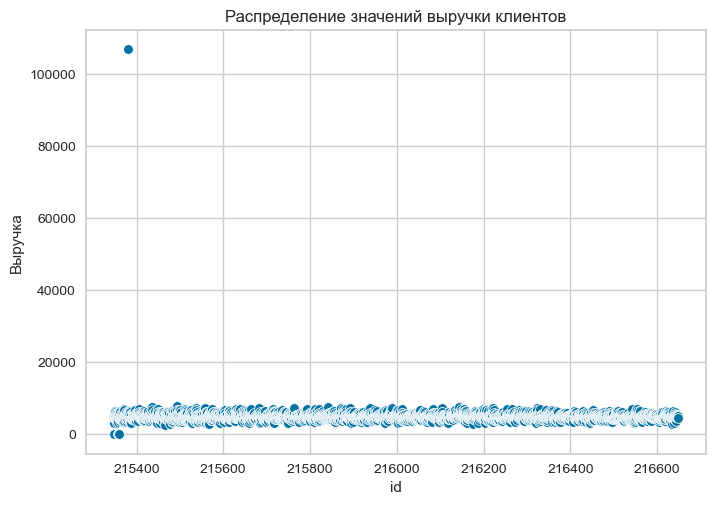

In [30]:
sns.scatterplot(x=market_money['id'], y=market_money['Выручка'])
plt.title('Распределение значений выручки клиентов')
plt.show()

На графике видно, что данное значение является аномально большим в сравнении с основной массой данных.

Чтобы понять, как лучше обработать аномальное значение, посмотрим на данные по клиенту с этим id.

In [31]:
market_money[market_money['Выручка']==market_money['Выручка'].max()]

,id,Период,Выручка
98,215380,текущий_месяц,106862.2


In [32]:
market_money[market_money['id']==215380]

,id,Период,Выручка
96,215380,препредыдущий_месяц,5051.0
97,215380,предыдущий_месяц,6077.0
98,215380,текущий_месяц,106862.2


Исходя из данных по клиенту с аномалией и остальным клиентам, можно сделать вывод, что значение выручки в текущем месяце в размере 106862,2 явялется ошибочным. Если оставить такое аномально высокое значение, оно будет мешать в дальнейшем анализе данных и построении модели. Совсем удалить значение тоже не является подходящим вариантом, так как у клиента в предыдущих двух месяцах были покупки. Соответственно, значение выручки по данному клиенту можно заменить на среднее значение по выручке за предыдущие два месяца, в которых он совершал покупки.

In [33]:
market_money.loc[(market_money['id']==215380)&(market_money['Период']=='текущий_месяц'), 'Выручка'] = \
market_money[(market_money['id']==215380)&(market_money['Период']!='текущий_месяц')]['Выручка'].sum()/2

Теперь снова посмотрим на график распределения значений выручки по клиентам.

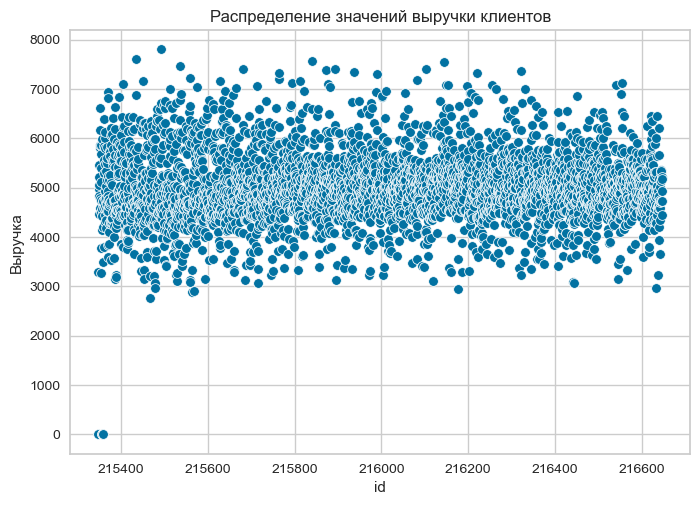

In [34]:
sns.scatterplot(x=market_money['id'], y=market_money['Выручка'])
plt.title('Распределение значений выручки клиентов')
plt.show()

Аномальное значение обработано.

**Market_time**

In [35]:
market_time['минут'].describe()

count    2600.000000
mean       13.336154
std         4.080198
min         4.000000
25%        10.000000
50%        13.000000
75%        16.000000
max        23.000000
Name: минут, dtype: float64

Исходя из описания данных, аномалии в данных отсутствуют.

**Money**

In [36]:
money['Прибыль'].describe()

count    1300.000000
mean        3.996631
std         1.013722
min         0.860000
25%         3.300000
50%         4.045000
75%         4.670000
max         7.430000
Name: Прибыль, dtype: float64

Аномалии в данных отсутствуют.

**Вывод:**
- во всех датасетах была проведена проверка наличия неявных и явных дубликатов. В датасетах `market_file` и `market_time` значения были обработаны в соответствие с выявленными факторами.
- данные были проверены на наличие аномалий. В датасете `market_money` было выявлено аномально высокое значение выручки в месяц по одному из клиентов. Данное значение было обработано.

## Исследовательский анализ данных 
<a id="analysis"></a>

### Статистический анализ признаков в датафрейме *market_file*

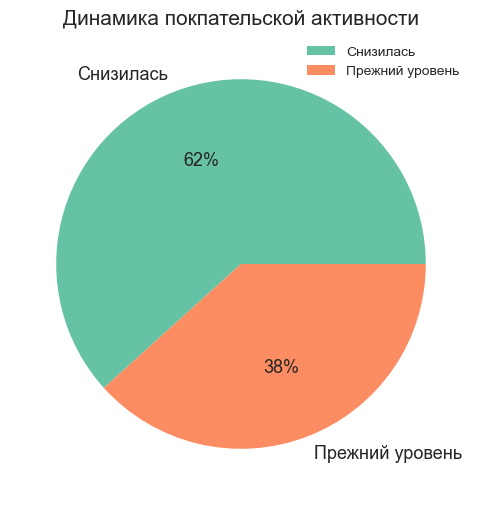

In [37]:
(market_file
 .pivot_table(index='Покупательская активность', values='id', aggfunc='count')
 .reset_index()
 .plot(kind='pie', x='Покупательская активность', y='id', figsize=(10,6), labels=market_file['Покупательская активность'].unique(),\
       autopct = "%.0f%%", ylabel='', textprops={'fontsize':13}, colors=sns.color_palette('Set2'))
)
plt.legend(loc='upper right')
plt.title('Динамика покпательской активности', size=15)
plt.show()

По распределению покупательской активности видно, что у 62% покупателей снизилась покупательская активность. Необходимо проанализировать другие признаки, чтобы понять, с чем может быть связан такой результат.

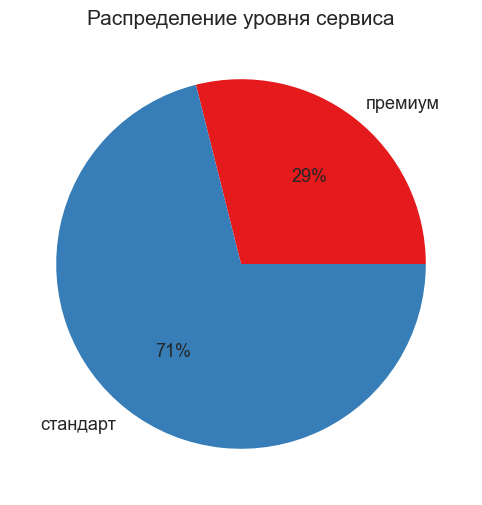

In [38]:
(market_file
 .pivot_table(index='Тип сервиса', values='id', aggfunc='count')
 .reset_index()
 .plot(kind='pie', x='Тип сервиса', y='id', figsize=(10,6), labels=market_file['Тип сервиса'].unique(),\
       autopct = "%.0f%%", ylabel='', textprops={'fontsize':13}, colors=sns.color_palette('Set1'), legend=None)
)

plt.title('Распределение уровня сервиса', size=15)
plt.show()

Большинство покупателей пользуются уровнем сервиса "стандарт" - 71% от общего числа покупателей.

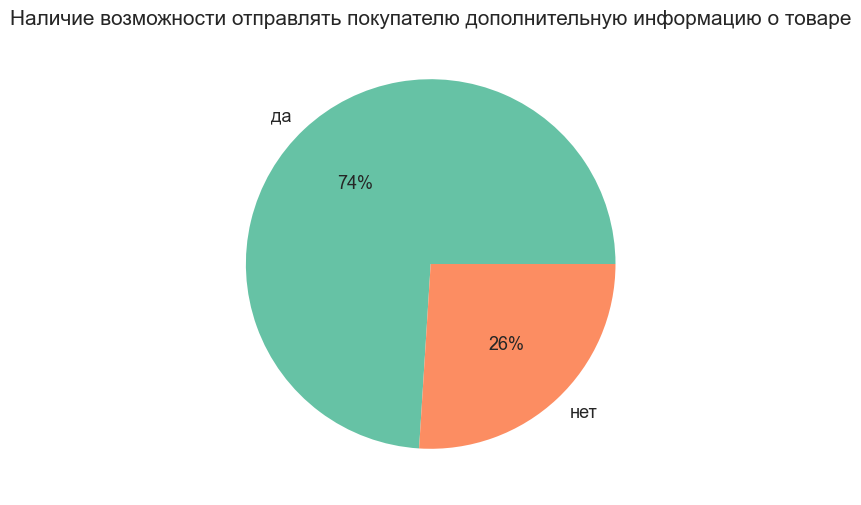

In [39]:
(market_file
 .pivot_table(index='Разрешить сообщать', values='id', aggfunc='count')
 .reset_index()
 .plot(kind='pie', x='Разрешить сообщать', y='id', figsize=(10,6), labels=market_file['Разрешить сообщать'].unique(),\
       autopct = "%.0f%%", ylabel='', textprops={'fontsize':13}, colors=sns.color_palette('Set2'), legend=None)
)

plt.title('Наличие возможности отправлять покупателю дополнительную информацию о товаре', size=15)
plt.show()

Большинство покупателей (74%) дало свое согласие, на получение дополнительной информации о товаре. Наличие согласий от большинства покупателей на рассылку информации дает возможности более продуктивной коммуникации с ними, что может быть инструментом увеличения продаж.

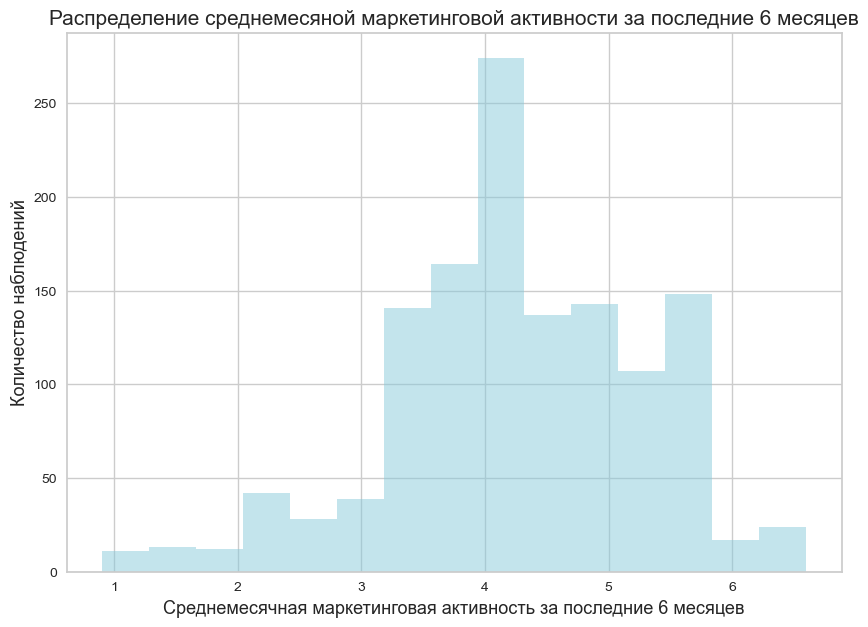

In [40]:
plt.figure(figsize=(10,7))
plt.hist(market_file['Маркет_актив_6_мес'], bins=15, color='c', alpha=0.5)
plt.xlabel('Среднемесячная маркетинговая активность за последние 6 месяцев', size=13)
plt.ylabel('Количество наблюдений', size=13)
plt.title('Распределение среднемесяной маркетинговой активности за последние 6 месяцев', size=15)
plt.show()

За последние шесть месяцев значение среднемесячной маркетинговой активности в большинстве случаев составляло от 3 до 6. Также виден пик в районе значения 4.

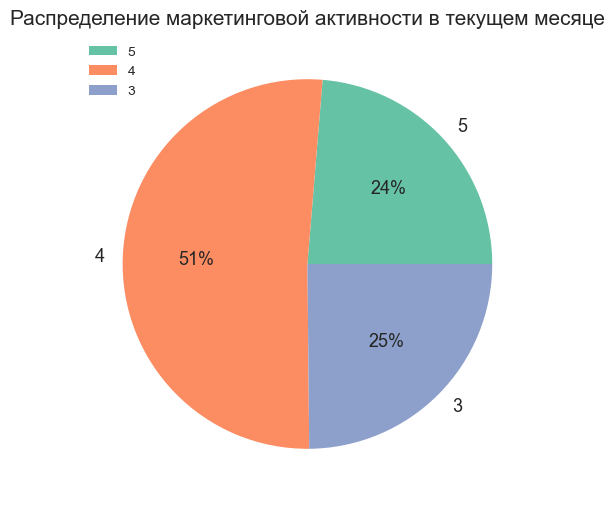

In [41]:
(market_file
 .pivot_table(index='Маркет_актив_тек_мес', values='id', aggfunc='count')
 .reset_index()
 .plot(kind='pie', x='Маркет_актив_тек_мес', y='id', figsize=(10,6), labels=market_file['Маркет_актив_тек_мес'].unique(),\
       autopct = "%.0f%%", ylabel='', textprops={'fontsize':13}, colors=sns.color_palette('Set2'))
)
plt.legend(loc='upper left')
plt.title('Распределение маркетинговой активности в текущем месяце', size=15)
plt.show()

В текущем месяце количество маркетинговых коммуникаций с клиентами принимало значения 3, 4 и 5. Чуть больше половины клиентов в текущем месяце получили маркетинговые рассылки/ звонки/ показ рекламы 4 раза. Четверть клиентов 5 раз была задействована в маркетинговых коммуникациях и оставшаяся четверть - 3 раза.

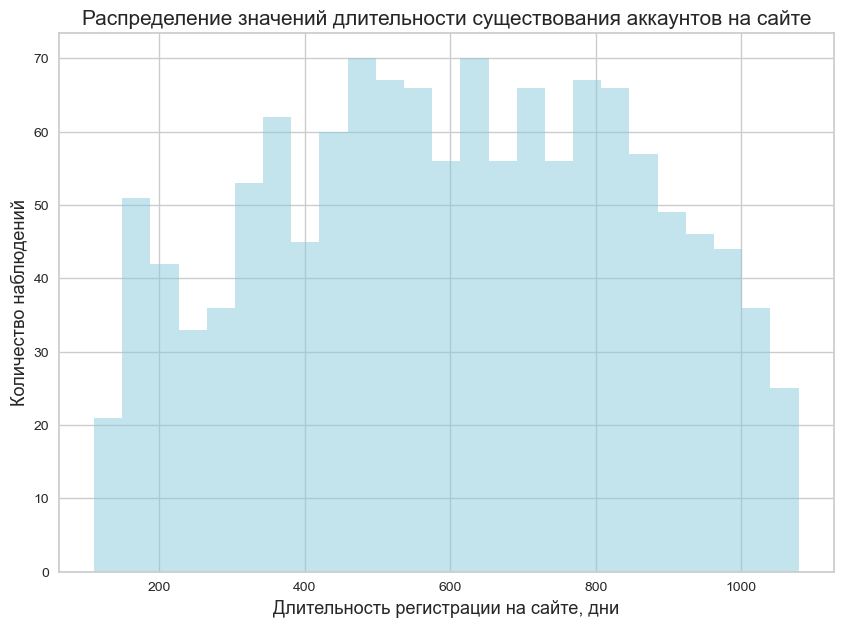

In [42]:
plt.figure(figsize=(10,7))
plt.hist(market_file['Длительность'], bins=25, color='c', alpha=0.5)
plt.xlabel('Длительность регистрации на сайте, дни', size=13)
plt.ylabel('Количество наблюдений', size=13)
plt.title('Распределение значений длительности существования аккаунтов на сайте', size=15)
plt.show()

Пользователи в выборке зарегистрированы на сайте примерно от 100 до 1100 дней. При этом стоит отметить, что на гистрограмме нет сильно выдающихся пиков (вероятно не было периодов, когда резко увеличивалось количество регистраций на сайте). Минимальное значение длительности регистрации на сайте составляет около 100 дней, то есть последний зарегистрированный пользователь пришел около ста дней назад. В данном случае, это может быть связано с тем, что у компании на текущий момент имеются трудности с привлечением новых клиентов. 

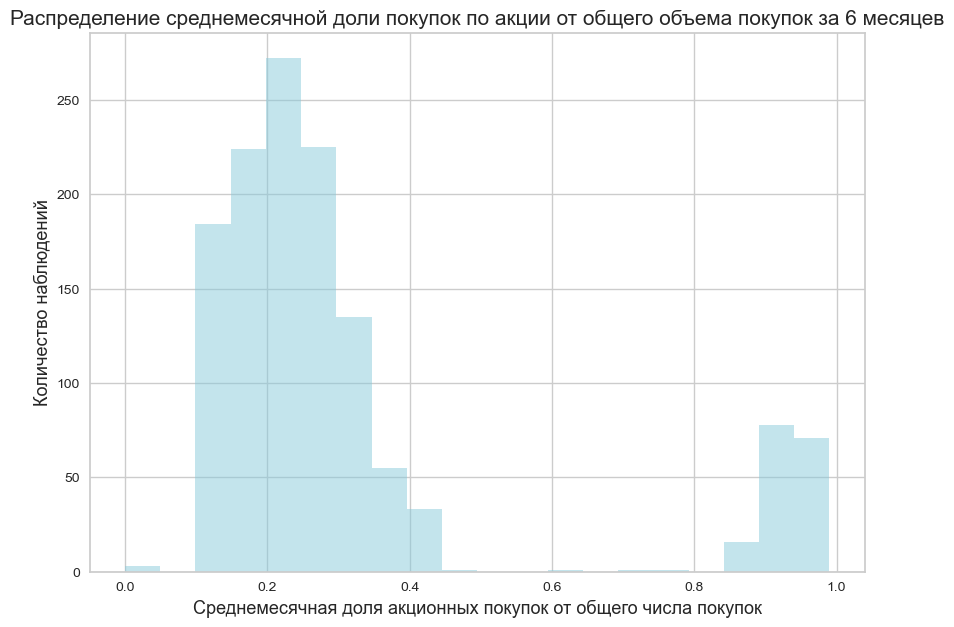

In [43]:
plt.figure(figsize=(10,7))
plt.hist(market_file['Акционные_покупки'], bins=20, color='c', alpha=0.5)
plt.xlabel('Среднемесячная доля акционных покупок от общего числа покупок', size=13)
plt.ylabel('Количество наблюдений', size=13)
plt.title('Распределение среднемесячной доли покупок по акции от общего объема покупок за 6 месяцев', size=15)
plt.show()

На графике выше видно, что чаще всего средняя доля акционных покупок пользователей составляла от 10% до 40%. Также видена небольшая группа пользователей, среднемесячная доля покупок которых составляет около 90% - они покупают в основном только акционные продукты.

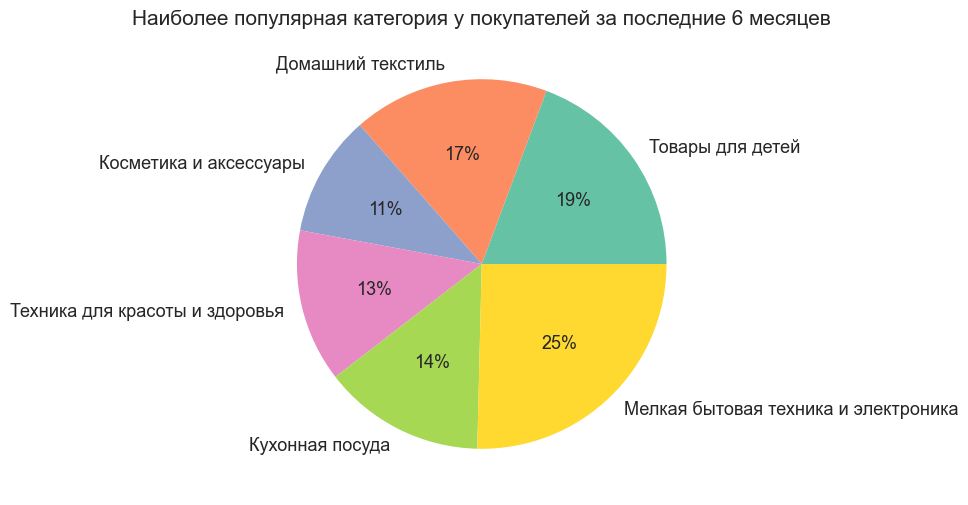

In [44]:
(market_file
 .pivot_table(index='Популярная_категория', values='id', aggfunc='count')
 .reset_index()
 .plot(kind='pie', x='Популярная_категория', y='id', figsize=(10,6), labels=market_file['Популярная_категория'].unique(),\
       autopct = "%.0f%%", ylabel='', textprops={'fontsize':13}, colors=sns.color_palette('Set2'), legend=None)
)

plt.title('Наиболее популярная категория у покупателей за последние 6 месяцев', size=15)
plt.show()

Всего на сайте представлено 6 категорий товаров. Наиболее популярной категорией является мелкая бытовая техника и электроника (25%). Далее по популярности идут категории Товары для детей (19%) и Домашний текстиль (17%). 

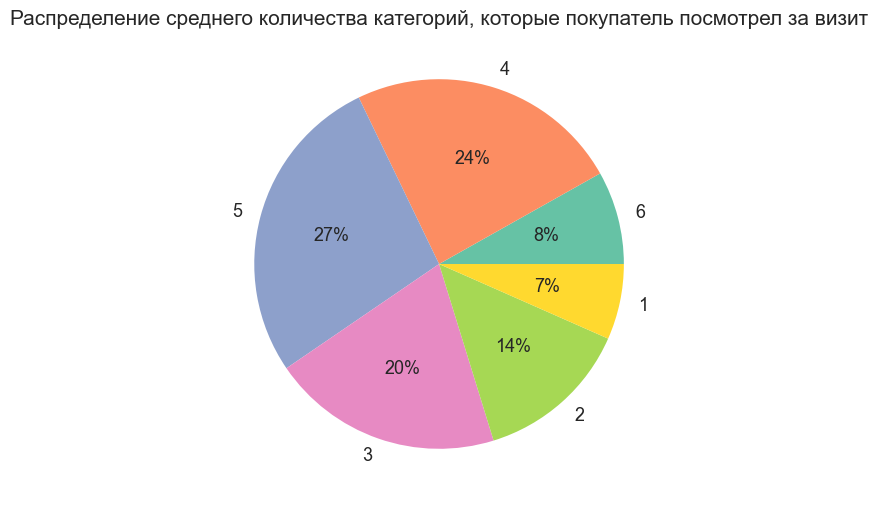

In [45]:
(market_file
 .pivot_table(index='Средний_просмотр_категорий_за_визит', values='id', aggfunc='count')
 .reset_index()
 .plot(kind='pie', x='Средний_просмотр_категорий_за_визит', y='id', figsize=(10,6), \
       labels=market_file['Средний_просмотр_категорий_за_визит'].unique(),\
       autopct = "%.0f%%", ylabel='', textprops={'fontsize':13}, colors=sns.color_palette('Set2'), legend=None)
)

plt.title('Распределение среднего количества категорий, которые покупатель посмотрел за визит', size=15)
plt.show()

Чаще всего за один визит покупатели просматривают от 3 до 5 категорий. Горахдо  еньший процент позьзователей за визит просматривает 2, 1 или 6 категорий товаров.

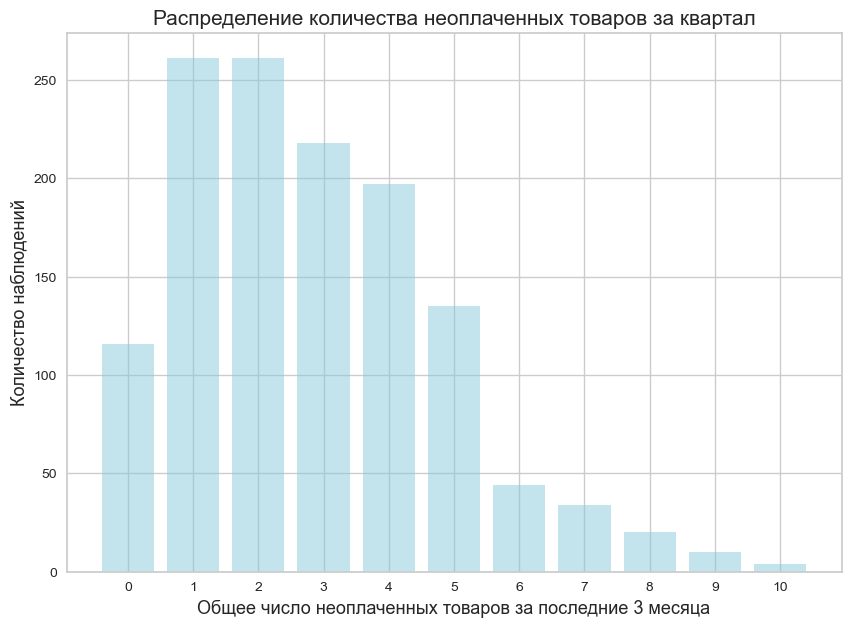

In [46]:
plt.figure(figsize=(10,7))
list_x = market_file['Неоплаченные_продукты_штук_квартал'].value_counts().sort_values(ascending=False).index
plt.bar(x=list_x, \
        height=market_file['Неоплаченные_продукты_штук_квартал'].value_counts(),\
        color='c', alpha=0.5)
plt.xlabel('Общее число неоплаченных товаров за последние 3 месяца', size=13)
plt.xticks(list_x)
plt.ylabel('Количество наблюдений', size=13)
plt.title('Распределение количества неоплаченных товаров за квартал', size=15)
plt.show()

У большинства клиентов за послений квартал было от 1 до 5 неоплаченных товаров. Гораздо меньшее количество клиентов в последндние 3 квартала имело от 6 до 10 неоплаченных товаров в корзине.

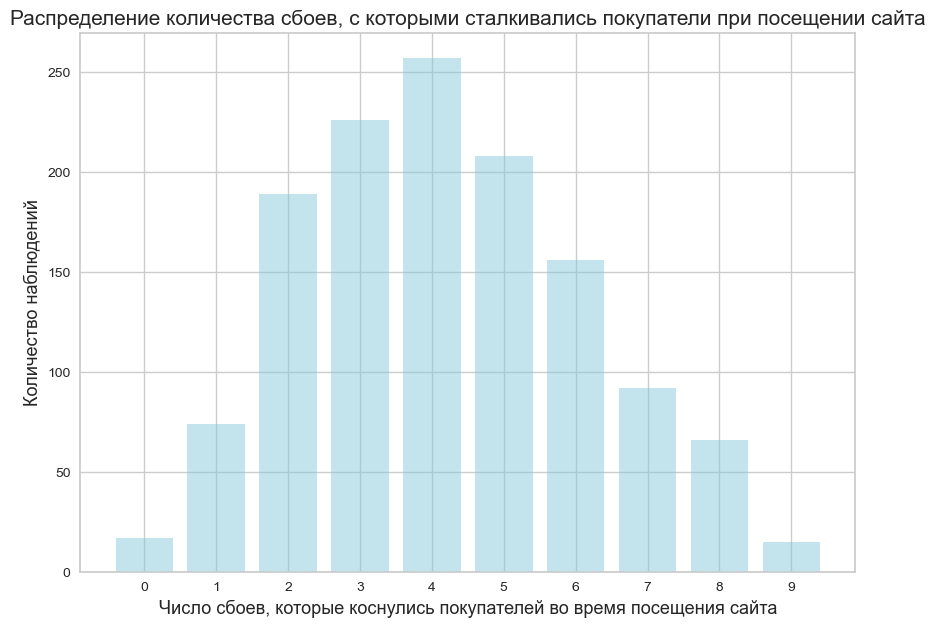

In [47]:
plt.figure(figsize=(10,7))
list_x = market_file['Ошибка_сервиса'].value_counts().sort_values(ascending=False).index
plt.bar(x=list_x, \
        height=market_file['Ошибка_сервиса'].value_counts(),\
        color='c', alpha=0.5)
plt.xlabel('Число сбоев, которые коснулись покупателей во время посещения сайта', size=13)
plt.ylabel('Количество наблюдений', size=13)
plt.xticks(list_x)
plt.title('Распределение количества сбоев, с которыми сталкивались покупатели при посещении сайта', size=15)
plt.show()

В целом пользователи сталкивались максимум с 9 сбоями при визите сайта. В основном, количество сбоев, коснувшихся покупателей, составляет 4. Стоит обратить внимание на стабильность работы сайта, так как этот показатель может влиять на клиентский опыт и общее впечатление о площадке.

Проверим распределение на нормальность с помощью теста Шапиро-Уилка (в качестве нулевой гипотезы предполагается, что распределение нормальное).

In [48]:
stat, p_value = st.shapiro(market_file['Ошибка_сервиса'])
print('Shapiro-Wilk p-value:', p_value)
if p_value > 0.05:
    print('Распределение можно считать близким к нормальному')
else:
    print('Распределение отклоняется от нормальности')

Shapiro-Wilk p-value: 6.207569190862092e-17
Распределение отклоняется от нормальности


In [49]:
# тест на нормальность распределения признаков
for x in market_file.drop('id', axis=1).select_dtypes(include='number').columns:
    stat, p_value = st.shapiro(market_file[x])
    print(x)
    print('Shapiro-Wilk p-value:', p_value)
    if p_value > 0.05:
        print('Распределение можно считать близким к нормальному', '\n')
    else:
        print('Распределение отклоняется от нормальности', '\n')

Маркет_актив_6_мес
Shapiro-Wilk p-value: 3.346556379763439e-13
Распределение отклоняется от нормальности 

Маркет_актив_тек_мес
Shapiro-Wilk p-value: 7.390260781668095e-37
Распределение отклоняется от нормальности 

Длительность
Shapiro-Wilk p-value: 5.787651462270672e-15
Распределение отклоняется от нормальности 

Акционные_покупки
Shapiro-Wilk p-value: 6.185281606977211e-45
Распределение отклоняется от нормальности 

Средний_просмотр_категорий_за_визит
Shapiro-Wilk p-value: 4.3522844141663915e-24
Распределение отклоняется от нормальности 

Неоплаченные_продукты_штук_квартал
Shapiro-Wilk p-value: 1.0150092614851186e-23
Распределение отклоняется от нормальности 

Ошибка_сервиса
Shapiro-Wilk p-value: 6.207569190862092e-17
Распределение отклоняется от нормальности 

Страниц_за_визит
Shapiro-Wilk p-value: 1.261430117529227e-14
Распределение отклоняется от нормальности 



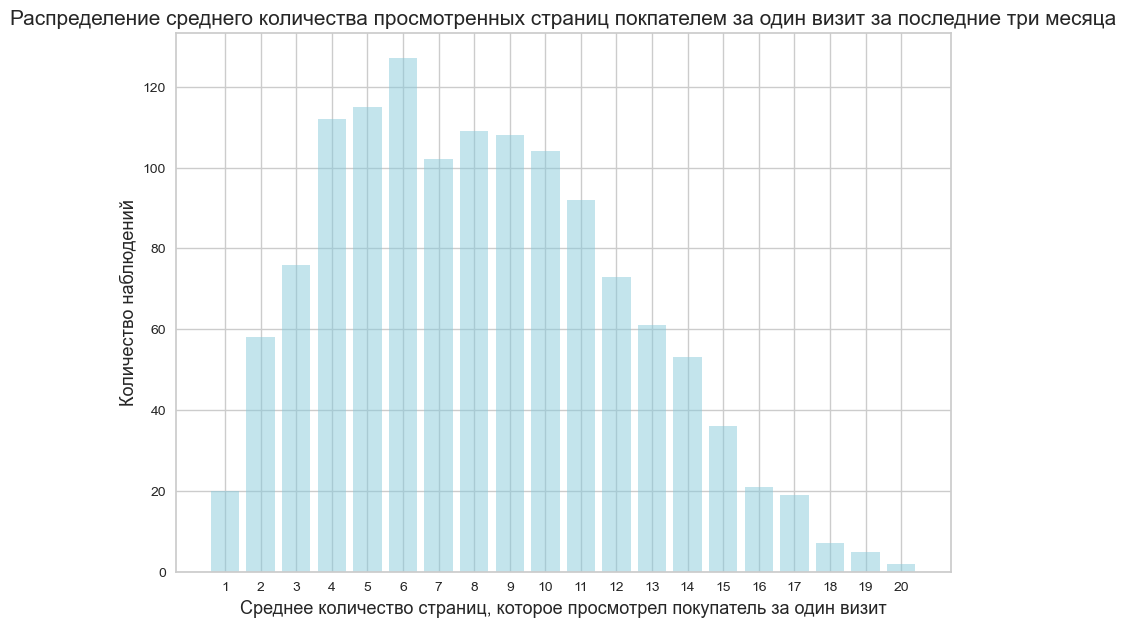

In [50]:
plt.figure(figsize=(10,7))
list_x = market_file['Страниц_за_визит'].value_counts().sort_values(ascending=False).index
plt.bar(x=list_x, \
        height=market_file['Страниц_за_визит'].value_counts(),\
        color='c', alpha=0.5)
plt.xlabel('Среднее количество страниц, которое просмотрел покупатель за один визит', size=13)
plt.ylabel('Количество наблюдений', size=13)
plt.xticks(list_x)
plt.title('Распределение среднего количества просмотренных страниц покпателем за один визит за последние три месяца', size=15)
plt.show()

Основная масса покупателей за один визит в среднем просматривает от 3 до 12 страниц.Большое количество просмотренных страниц, может говорить о том, что покупатель интересовался несколькими товарами, либо испытывал трудности при поиске подходящего товара.

**Вывод:**
- По распределению покупательской активности видно, что у 62% покупателей снизилась покупательская активность. Необходимо проанализировать другие признаки, чтобы понять, с чем может быть связан такой результат.
- Большинство покупателей пользуются уровнем сервиса "стандарт" - 71% от общего числа покупателей.
- Большинство покупателей (74%) дало свое согласие, на получение дополнительной информации о товаре.
- За последние шесть месяцев значение среднемесячной маркетинговой активности в большинстве случаев составляло от 3 до 6. Также виден пик в районе значения 4.
- В текущем месяце количество маркетинговых коммуникаций с клиентами принимало значения 3, 4 и 5. Чуть больше половины клиентов в текущем месяце получили маркетинговые рассылки/ звонки/ показ рекламы 4 раза. Четверть клиентов 5 раз была задействована в маркетинговых коммуникациях и оставшаяся четверть - 3 раза.
- Пользователи в выборке зарегистрированы на сайте примерно от 100 до 1100 дней. При этом стоит отметить, что на гистрограмме нет сильно выдающихся пиков (вероятно не было периодов, когда резко увеличивалось количество регистраций на сайте). Минимальное значение длительности регистрации на сайте составляет около 100 дней, то есть последний зарегистрированный пользователь пришел около ста дней назад.
- чаще всего средняя доля акционных покупок пользователей составляла от 10% до 40%. Также видена небольшая группа пользователей, среднемесячная доля покупок которых составляет около 90% - они покупают в основном только акционные продукты.
- Всего на сайте представлено 6 категорий товаров. Наиболее популярной категорией является мелкая бытовая техника и электроника (25%). Далее по популярности идут категории Товары для детей (19%) и Домашний текстиль (17%). 
- Чаще всего за один визит покупатели просматривают от 3 до 5 категорий. Горахдо  еньший процент позьзователей за визит просматривает 2, 1 или 6 категорий товаров.
- У большинства клиентов за послений квартал было от 1 до 5 неоплаченных товаров. Гораздо меньшее количество клиентов в последнем квартале имело от 6 до 10 неоплаченных товаров в корзине.
- В целом пользователи сталкивались максимум с 9 сбоями при визите сайта. В основном, количество сбоев, коснувшихся покупателей, составляет 4. Стоит обратить внимание на стабильность работы сайта.

### Статистический анализ признаков в датафрейме *market_money*

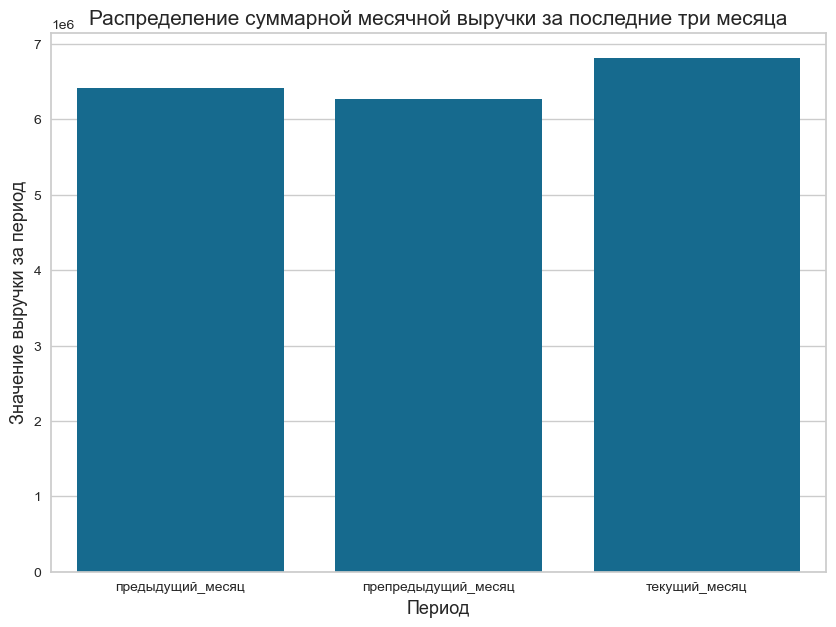

In [51]:
plt.figure(figsize=(10,7))
a=market_money.pivot_table(index='Период', values='Выручка', aggfunc='sum').reset_index()
sns.barplot(x=a['Период'], y=a['Выручка'])

plt.xlabel('Период', size=13)
plt.ylabel('Значение выручки за период', size=13)
plt.title('Распределение суммарной месячной выручки за последние три месяца', size=15)
plt.show()

Исходя из диаграммы выше, в последние три месяца суммарная месяная выручка изменялась незначительно. В последние три месяца месячная выручка находилась в промежутке от 6 до 7 млн. Чуть больше, чем в остальные месяцы, была выручка в текущем месяце. 

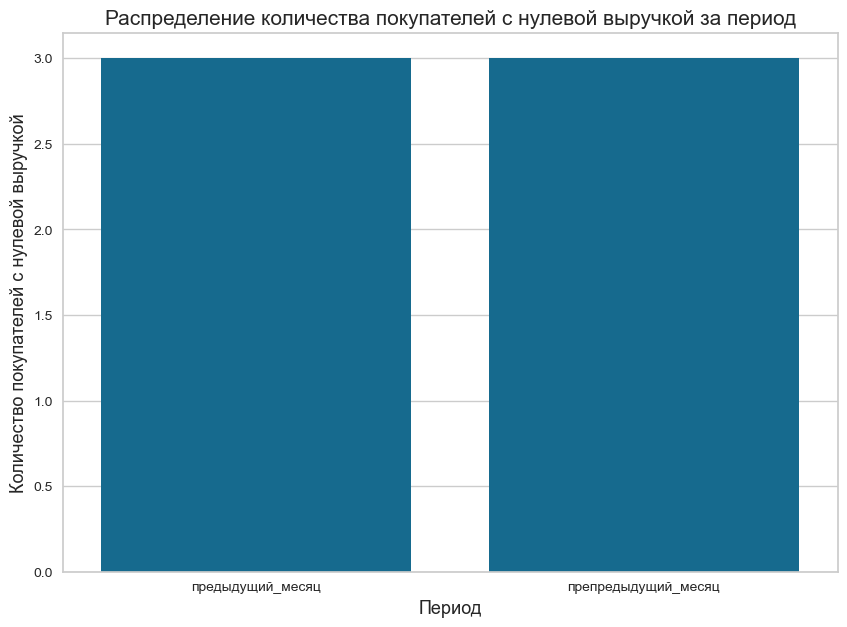

In [52]:
plt.figure(figsize=(10,7))
a=market_money[market_money['Выручка']==0].pivot_table(index='Период', values='Выручка', aggfunc='count').reset_index()
sns.barplot(x=a['Период'], y=a['Выручка'])

plt.xlabel('Период', size=13)
plt.ylabel('Количество покупателей с нулевой выручкой', size=13)
plt.title('Распределение количества покупателей с нулевой выручкой за период', size=15)
plt.show()

Покупатели с нулевой выручкой практически отсутствуют. В текщем месяце таких покупателей не было совсем, в два предыдущих периода - по 3 покупателя.

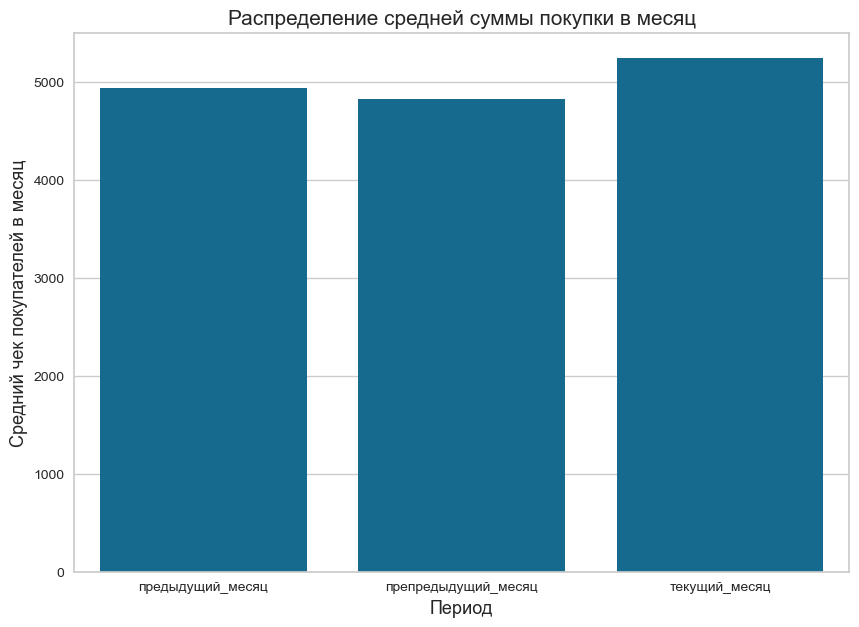

In [53]:
plt.figure(figsize=(10,7))
a=market_money.pivot_table(index='Период', values='Выручка').reset_index()
sns.barplot(x=a['Период'], y=a['Выручка'])

plt.xlabel('Период', size=13)
plt.ylabel('Средний чек покупателей в месяц', size=13)
plt.title('Распределение средней суммы покупки в месяц', size=15)
plt.show()

В среднем в месяц один покупатель совершает покупки на сумму около 5 тысяч. В текущем месяца самое высокое значение среднемесячного чека - чуть больше 5 тысяч рублей.

**Вывод:**
- Исходя из диаграммы выше, в последние три месяца суммарная месяная выручка изменялась незначительно. В последние три месяца месячная выручка находилась в промежутке от 6 до 7 млн. Чуть больше, чем в остальные месяцы, была выручка в текущем месяце.
- Покупатели с нулевой выручкой практически отсутствуют. В текщем месяце таких покупателей не было совсем, в два предыдущих периода - по 3 покупателя.
- В среднем в месяц один покупатель совершает покупки на сумму около 5 тысяч. В текущем месяца самое высокое значение среднемесячного чека - чуть больше 5 тысяч рублей.

### Статистический анализ признаков в датафрейме *market_time*

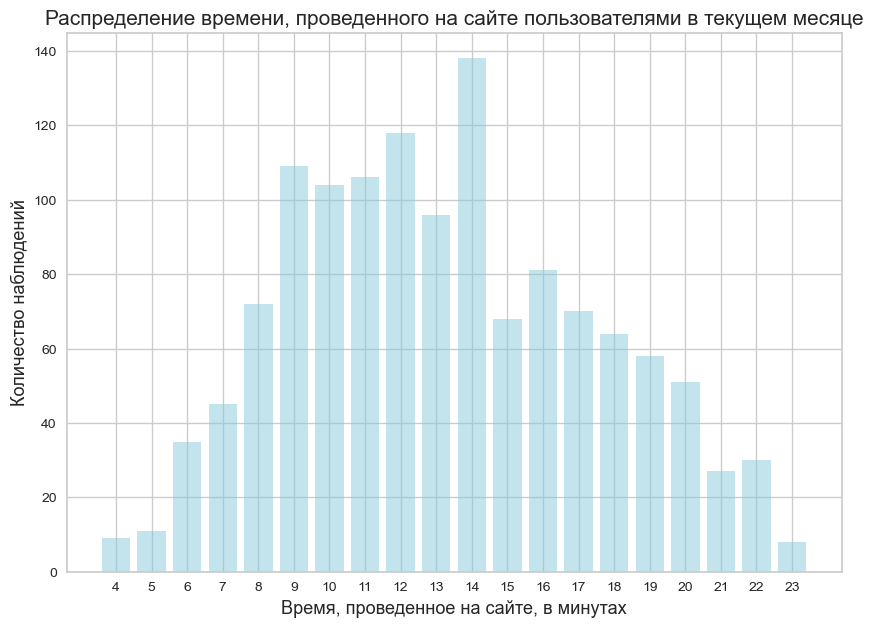

In [54]:
plt.figure(figsize=(10,7))
list_x = market_time.loc[market_time['Период']=='текущий_месяц', 'минут'].value_counts().sort_values(ascending=False).index
plt.bar(x=list_x, \
        height=market_time.loc[market_time['Период']=='текущий_месяц', 'минут'].value_counts(),\
        color='c', alpha=0.5)
plt.xlabel('Время, проведенное на сайте, в минутах', size=13)
plt.ylabel('Количество наблюдений', size=13)
plt.xticks(list_x)
plt.title('Распределение времени, проведенного на сайте пользователями в текущем месяце', size=15)
plt.show()

В текущем месяце пользователи проводили на сайте в основном от 8 до 20 минут. При чем, внутри этого интервала, большая часть пользователей проводило на сайте от 8 до 15 минут (оставшаяся часть - от 15 до 20).

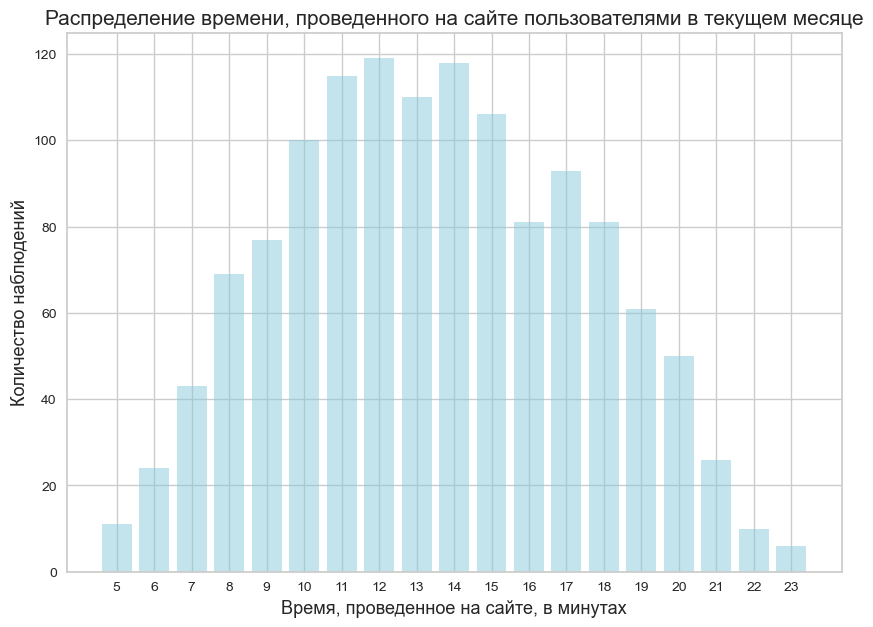

In [55]:
plt.figure(figsize=(10,7))
list_x = market_time.loc[market_time['Период']=='предыдущий_месяц', 'минут'].value_counts().sort_values(ascending=False).index
plt.bar(x=list_x, \
        height=market_time.loc[market_time['Период']=='предыдущий_месяц', 'минут'].value_counts(),\
        color='c', alpha=0.5)
plt.xlabel('Время, проведенное на сайте, в минутах', size=13)
plt.ylabel('Количество наблюдений', size=13)
plt.xticks(list_x)
plt.title('Распределение времени, проведенного на сайте пользователями в текущем месяце', size=15)
plt.show()

In [56]:
stat, p_value = st.shapiro(market_time.loc[market_time['Период']=='предыдущий_месяц', 'минут'])
print('Shapiro-Wilk p-value:', p_value)
if p_value > 0.05:
    print('Распределение можно считать близким к нормальному')
else:
    print('Распределение отклоняется от нормальности')

Shapiro-Wilk p-value: 2.834742081562704e-11
Распределение отклоняется от нормальности


Распределение времени, проведенного на сайте пользователями, нельзя считать близким к нормальному.

In [57]:
market_time.pivot_table(index='Период', values='минут', aggfunc='sum')

,минут
Период,
предыдущий_месяц,17508
текущий_месяц,17166


Суммарное количество минут, проведенных пользователями на сайте за последние два месяца значительно не изменялось.

**Вывод:**
- В текущем месяце пользователи проводили на сайте в основном от 8 до 20 минут. При чем, внутри этого интервала, большая часть пользователей проводило на сайте от 8 до 15 минут (оставшаяся часть - от 15 до 20).
- Суммарное количество минут, проведенных пользователями на сайте за последние два месяца значительно не изменялось.

### Статистический анализ признаков в датафрейме *money*

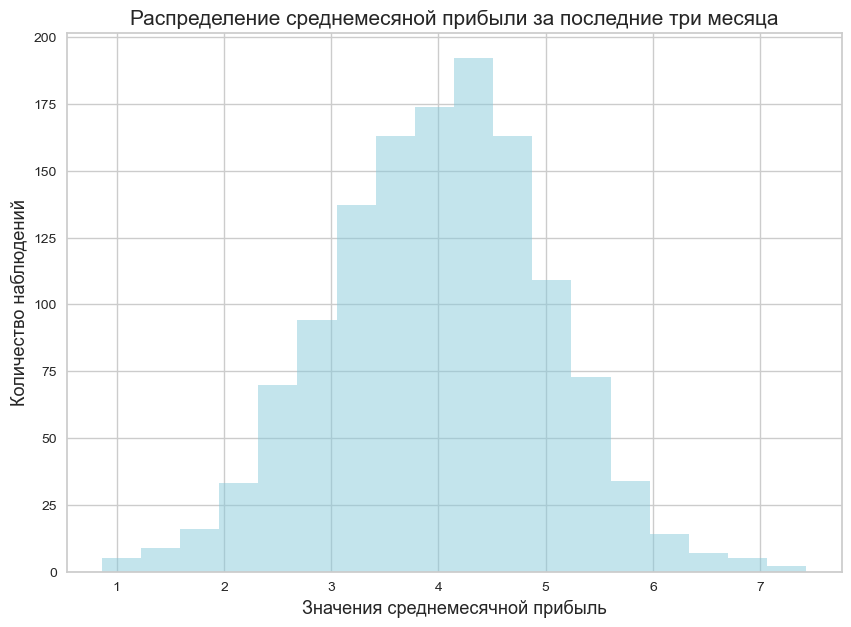

In [58]:
plt.figure(figsize=(10,7))
plt.hist(money['Прибыль'], bins=18, color='c', alpha=0.5)
plt.xlabel('Значения среднемесячной прибыль', size=13)
plt.ylabel('Количество наблюдений', size=13)
plt.title('Распределение среднемесяной прибыли за последние три месяца', size=15)
plt.show()

Распределение среднемесячной прибыли, которую магазин получает с продаж покупателю, похоже на нормальное. В среднем в месяц магазин получает с продаж покупателю прибыль в размере от 1 до 7.

**Вывод:**
- Распределение среднемесячной прибыли, которую магазин получает с продаж покупателю, похоже на нормальное. В среднем в месяц магазин получает с продаж покупателю прибыль в размере от 1 до 7.

## Объединение таблиц market_file.csv, market_money.csv, market_time.csv
<a id="merge"></a>

После проведенного исследовательского анализа данных во всех датафреймах, объединим данные в один датасет перед обучением модели.

Для начала сделаем столбцы с индентификатором клиента в каждой таблице индексами.

In [59]:
market_file = market_file.set_index('id')
market_money = market_money.set_index('id')
market_time = market_time.set_index('id')

При объединении таблиц нам нужно, чтобы данные по каждому периоду находились в отдельном столбце. Поэтому обработаем данные в датафреймах `market_money`, `market_time`.

In [60]:
market_money['Выручка_тек_мес'] = market_money[market_money['Период']=='текущий_месяц']['Выручка']
market_money['Выручка_пред_мес'] = market_money[market_money['Период']=='предыдущий_месяц']['Выручка']
market_money['Выручка_пре_пред_мес'] = market_money[market_money['Период']=='препредыдущий_месяц']['Выручка']
market_money = market_money.reset_index().drop(['Период', 'Выручка'], axis=1).drop_duplicates().set_index('id')
market_money

,Выручка_тек_мес,Выручка_пред_мес,Выручка_пре_пред_мес
id,,,
215348,3293.1,0.0,0.0
215349,4971.6,5216.0,4472.0
215350,5058.4,5457.5,4826.0
215351,6610.4,6158.0,4793.0
215352,5872.5,5807.5,4594.0
...,...,...,...
216643,4741.7,3664.0,4704.0
216644,5353.0,4729.0,5299.0
216645,5139.2,5160.0,5334.0


In [61]:
market_time['минут_тек_мес'] = market_time[market_time['Период']=='текущий_месяц']['минут']
market_time['минут_пред_мес'] = market_time[market_time['Период']=='предыдущий_месяц']['минут']
market_time = market_time.reset_index().drop(['Период', 'минут'], axis=1).drop_duplicates().set_index('id')
market_time

,минут_тек_мес,минут_пред_мес
id,,
215348,14,13
215349,10,12
215350,13,8
215351,13,11
215352,11,8
...,...,...
216643,7,14
216644,11,12
216645,18,12


Данные в датафрейме подготовлены, теперь можно приступать к объединению.

In [62]:
market_file = market_file.merge(market_money, how='left', on='id')
market_file = market_file.merge(market_time, how='left', on='id')
market_file.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1300 entries, 215348 to 216647
Data columns (total 17 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Покупательская активность            1300 non-null   object 
 1   Тип сервиса                          1300 non-null   object 
 2   Разрешить сообщать                   1300 non-null   object 
 3   Маркет_актив_6_мес                   1300 non-null   float64
 4   Маркет_актив_тек_мес                 1300 non-null   int64  
 5   Длительность                         1300 non-null   int64  
 6   Акционные_покупки                    1300 non-null   float64
 7   Популярная_категория                 1300 non-null   object 
 8   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 9   Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 10  Ошибка_сервиса                       1300 non-null   int64  
 11  Страниц_за_визит            

**Вывод:**
- были обработаны датафреймы market_money, market_time: данные по выручке и минутам были рахделены по столбцам, каждый их которых соответствует определенному периоду.
- датафремы market_money, market_time и market_file были объединены в один датафрейм по идентификатору покупателя.

In [63]:
p = ['Выручка_тек_мес', 'Выручка_пред_мес', 'Выручка_пре_пред_мес']
market_file_excl = market_file[(market_file[p[0]]==0)|(market_file[p[1]]==0)|(market_file[p[2]]==0)]
market_file_excl

,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит,Выручка_тек_мес,Выручка_пред_мес,Выручка_пре_пред_мес,минут_тек_мес,минут_пред_мес
id,,,,,,,,,,,,,,,,,
215348,Снизилась,премиум,да,3.4,5,121,0.0,Товары для детей,6,2,1,5,3293.1,0.0,0.0,14,13
215357,Снизилась,стандарт,да,3.9,5,154,0.0,Техника для красоты и здоровья,3,3,9,5,5986.3,0.0,0.0,6,12
215359,Снизилась,стандарт,да,4.6,5,110,0.0,Домашний текстиль,4,2,4,2,4735.0,0.0,0.0,11,13


У трех покупателей не наблюдается активность на протяжении всего периода (то есть трех месяцев). Исключим их из датасета.

In [64]:
market_file = market_file.drop(index=market_file_excl.index)
print('Shape:',market_file.shape)
market_file.info()

Shape: (1297, 17)
<class 'pandas.core.frame.DataFrame'>
Index: 1297 entries, 215349 to 216647
Data columns (total 17 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Покупательская активность            1297 non-null   object 
 1   Тип сервиса                          1297 non-null   object 
 2   Разрешить сообщать                   1297 non-null   object 
 3   Маркет_актив_6_мес                   1297 non-null   float64
 4   Маркет_актив_тек_мес                 1297 non-null   int64  
 5   Длительность                         1297 non-null   int64  
 6   Акционные_покупки                    1297 non-null   float64
 7   Популярная_категория                 1297 non-null   object 
 8   Средний_просмотр_категорий_за_визит  1297 non-null   int64  
 9   Неоплаченные_продукты_штук_квартал   1297 non-null   int64  
 10  Ошибка_сервиса                       1297 non-null   int64  
 11  Страниц_за

## Корреляционный анализ признаков в объединенном датасете
<a id="corr"></a>

Поскольку при проведении исследовательского анализа было выявлено, что не все признаки распределены нормально, для проведения корреляционного анализа используем корреляцию Спирмана.

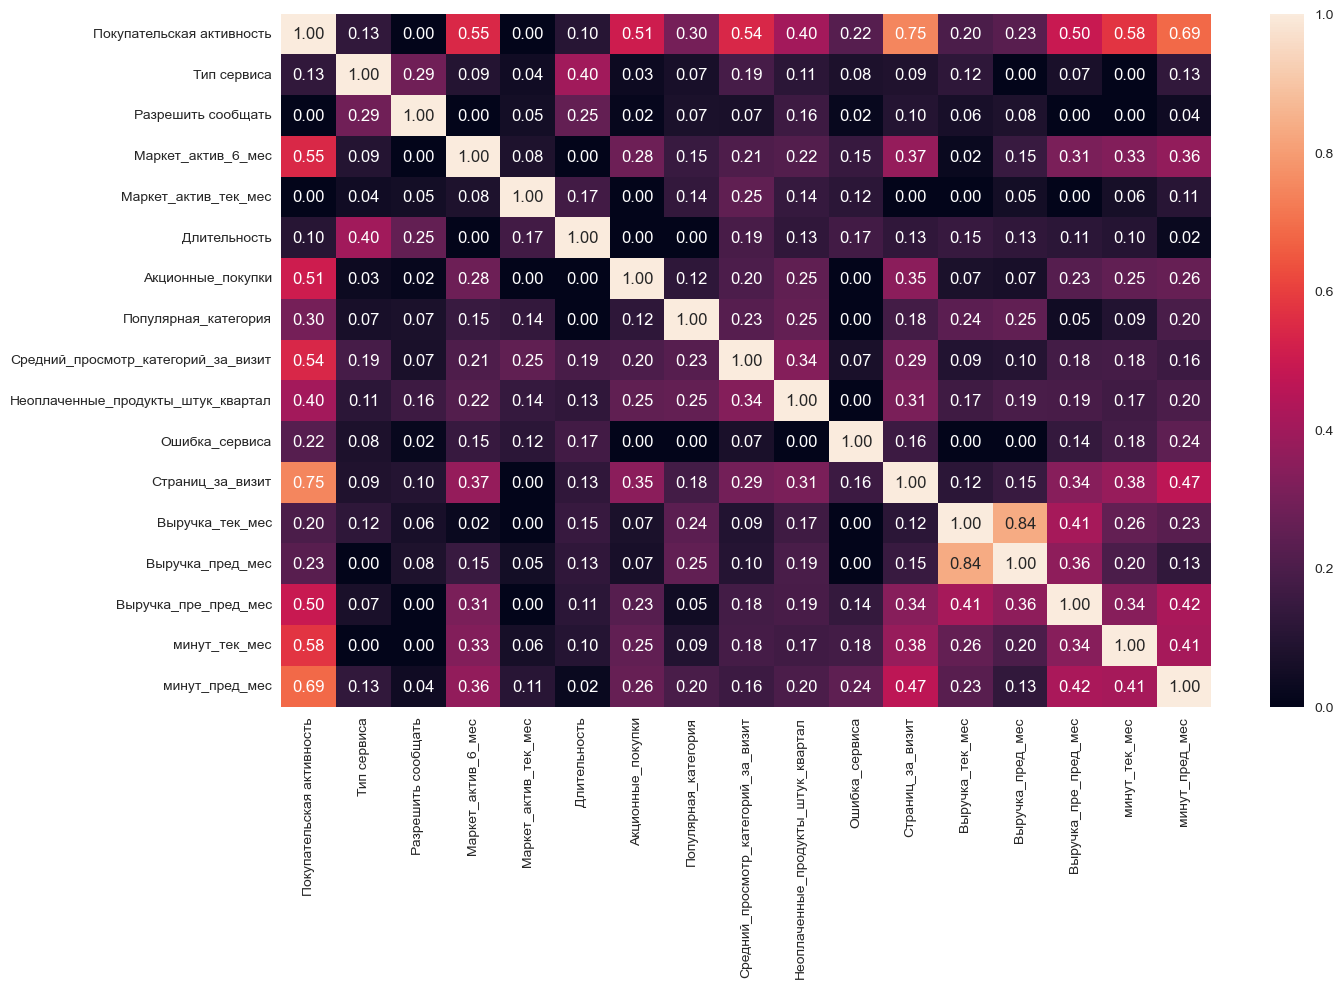

In [65]:
plt.figure(figsize=(15, 9))
list_interval=['Маркет_актив_6_мес', 'Длительность', 'Акционные_покупки', 'Выручка_тек_мес', 'Выручка_пред_мес', 'Выручка_пре_пред_мес', 'минут_тек_мес', 'минут_пред_мес']
sns.heatmap(market_file.phik_matrix(interval_cols=list_interval), annot=True, fmt='.2f')
plt.show()

Как видно из таблицы выше, мультиколлинеарности между признаками не наблюдается.

Целевой признак (Покупательская активность) коррелирует со следующими входными признаками:
- *высокая корреляция*: среднее количество страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца
- *заметная корреляция*: количество минут проведенных на сайте, выручка в препредыдущий период, количество неоплаченных товаров за квартал, среднее количество просмотренных категорий за визит, акционные покупки и маркетинговая активность.

Заметная корреляция также наблюдаются между следующими входными признаками:
- значение выручки в предыдущий месяц и акционные покупки;
- значение выручки в препредыдущий месяц и акционные покупки;
- значение выручки в текущем месяце и значение выручки в предыдущем месяце;
- значение выручки в предыдущем месяце и значение выручки в препредыдущем месяце;
- количество страниц, просмотренных за визит и количество минут, проведенных на сайте в предыдущем месяце.

Изучив взаимосвязи между признаками, перейдем к обучению модели.

## Создание пайплайна
<a id="pipeline"></a>

Сперва разделим данные на тренировочную и тестовую выборки.

На этапе исследовательского нализа данных было выявлено, что значения целевого признака распределены по-разному: на класс "снизилась" приходится 62% наблюдений, на класс "прежний уровень" - 38%. Таким образом, нужно учесть дисбаланс данных.

In [66]:
# Выделим целевой и входные
X = market_file.drop('Покупательская активность', axis=1)
y = market_file['Покупательская активность']

In [67]:
# Разделим на тренировочную и тестовую выборки
RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = RANDOM_STATE, stratify=y)

# проверка получившихся выборок
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(972, 16)
(325, 16)
(972,)
(325,)


Для того чтобы составить итоговый пайплайн, нужно по частям описать каждый из шагов при обработке данных. 

Начнем с масштабирования количественных переменных и кодирования категориальных. Укажем наименования столбцов, где хранятся категориальные переменные для кодированияи количественные для масштабирования.

In [68]:
# укажем наименования столбцов
ohe_columns = ['Популярная_категория', 'Разрешить сообщать']
ord_columns = ['Тип сервиса']
num_columns = X.drop(['Тип сервиса', 'Разрешить сообщать', 'Популярная_категория'], axis=1).columns


Перед построением пайплайна, закодируем целевую переменную с помощью LabelEncoder.

In [69]:
label_encoder = LabelEncoder()
label_encoder.fit(y_train)

LabelEncoder()

In [70]:
y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

Теперь объединим шаги по кодированию и масштабированию переменных в пайплайн.

In [71]:
data_preprocessor = ColumnTransformer(
[
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ohe_columns),
    ('ord', OrdinalEncoder(), ord_columns),
    ('num', StandardScaler(), num_columns)
],
remainder='passthrough')

Теперь создадим итоговый пайплайн: подготовка данных и модель.

In [72]:
pipe_final = Pipeline(
[
    ('preprocessor', data_preprocessor),
    ('model', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

Теперь нам нужно перепребирать методы масштабирования, кодирования, разные модели и гиперпараметры этих моделей, чтобы найти наиболее оптимальное решение.

Проверим в работе 4 модели:
- Модель логистической регрессии (LogisticRegression)
- Модель к-ближайших соседей (KNeighborsClassifier)
- Дерево решений (DecisionTreeClassifier)
- Метод опорных векторов (SVC)

Для каждой из этих моделей также обохначим круг гиперпараметров, которые необходимо будет перебрать для подбора наиболее выигрышной конфигурации.

In [73]:
param_grid = [
    {
        'model': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'model__max_depth':range(2, 11),
        'model__min_samples_split':range(2, 6),
        'preprocessor__num':[StandardScaler(), MinMaxScaler(), 'passthrough']
    },
    {
        'model':[KNeighborsClassifier()],
        'model__n_neighbors':range(1,11),
        'preprocessor__num':[StandardScaler(), MinMaxScaler()]
    },
    {
        'model':[LogisticRegression(random_state=RANDOM_STATE, solver='liblinear', class_weight='balanced', max_iter=1000)],
        'model__C':[0.2, 0.6, 1],
        'preprocessor__num':[StandardScaler(), MinMaxScaler(), 'passthrough']
    },
    {
        'model':[SVC(random_state=RANDOM_STATE, probability=True, class_weight='balanced')],
        'model__kernel':['linear', 'rbf', 'poly', 'sigmoid'],
        'model__degree':range(2, 5),
        'preprocessor__num':[StandardScaler(), MinMaxScaler(), 'passthrough']
    }
]

Для оценки наилучшей модели необходимо использовать какую-либо метрику. По сути перед нами стоит задача бинарной классификации: два класса "снизилась" и "прежний уровень". При этом нам важны точные предсказания класса "снизилась", для того чтобы среагировать и поднять активность покупателя. Соответственно метрика accuracy не подходит. Используем метрику roc-auc.

С помощью GridSearchCV переберем все возможные варианты комбинаций и узнаем модель (и ее параметры) с наиболее высоким значением метрики.

In [74]:
grid = GridSearchCV(pipe_final, param_grid=param_grid, cv=5, scoring='roc_auc', n_jobs=-1)

In [75]:
grid.fit(X_train, y_train_encoded)

C:\Users\Anya\anaconda3\lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('ohe',
                                                                         OneHotEncoder(handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         ['Популярная_категория',
                                                                          'Разрешить '
                                                                          'сообщать']),
                                                                        ('ord',
                                                                         OrdinalEncoder(),
                                                                         ['Тип '
                                                                          'сервиса']),
                                                                        ('num',
                                                                         StandardScaler(),
                                                                         Index(['Маркет_актив_6_мес', 'Маркет_актив_тек_мес', 'Дл...
                                                       solver='liblinear')],
                          'model__C': [0.2, 0.6, 1],
                          'preprocessor__num': [StandardScaler(),
                                                MinMaxScaler(),
                                                'passthrough']},
                         {'model': [SVC(class_weight='balanced',
                                        probability=True, random_state=42)],
                          'model__degree': range(2, 5),
                          'model__kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
                          'preprocessor__num': [StandardScaler(),
                                                MinMaxScaler(),
                                                'passthrough']}],
             scoring='roc_auc')

In [76]:
print('Лучшая модель и её параметры:\n\n', grid.best_estimator_) 

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Популярная_категория',
                                                   'Разрешить сообщать']),
                                                 ('ord', OrdinalEncoder(),
                                                  ['Тип сервиса']),
                                                 ('num', StandardScaler(),
                                                  Index(['Маркет_актив_6_мес', 'Маркет_актив_тек_мес', 'Длительность',
       'Акционные_покупки', 'Средний_просмотр_категорий_за_визит',
       'Неоплаченные_продукты_штук_квартал', 'Ошибка_сервиса',
       'Страниц_за_визит',

In [77]:
print('Метрика ROC-AUC для лучшей модели:', round(grid.best_score_, 2)) 

Метрика ROC-AUC для лучшей модели: 0.92


Расчитаем прогнозные значения для тестовой выборки и на ней же оценим метрику roc-auc.

In [78]:
data_preprocessor.fit(X_train)
y_pred = grid.best_estimator_.named_steps['model'].predict(data_preprocessor.transform(X_test))
y_pred_proba = grid.best_estimator_.named_steps['model'].predict_proba(data_preprocessor.transform(X_test))[:,1]

In [79]:
print('Метрика ROC-AUC для лучшей модели:', round(roc_auc_score(y_test_encoded, y_pred_proba),2)) 

Метрика ROC-AUC для лучшей модели: 0.92


**Вывод:**

- Среди моделей LogisticRegression, KNeighborsClassifier, TreeDecisionClassifier, SVC лучшей моделью оказалась модель SVC со следующими параметрами: для масштабирования данных использован StandardScaler, в модели используется ядро *rbf*, а также параметр class_weight='balanced', который позволяет моделе качественнее работать с несбалансированными данными. 
- Для выбора лучшей модели было использовавно значение метрики roc-auc. Для лучшей модели значение метрики составило 0.92.

## Анализ важности признаков
<a id="importance"></a>

Теперь, когда модель выбрана, можно приступить к оценке важности входных признаков. Для оценки важности признаков можно использовать метод SHAP. Он поможет определить вклад признака в каждый прогноз.

Все нужные данные подготовлены, можно переходить к оценке важности признаков. 

In [80]:
data_train = pd.DataFrame(data_preprocessor.transform(X_train), columns=data_preprocessor.get_feature_names_out())
data_test = pd.DataFrame(data_preprocessor.transform(X_test), columns=data_preprocessor.get_feature_names_out())
explainer = shap.SamplingExplainer(lambda x: grid.best_estimator_.named_steps['model'].predict_proba(x)[:,1],\
                                                                              data_train)
shap_values = explainer(data_test)

  0%|          | 0/325 [00:00<?, ?it/s]

*Примечание: в случае некорректной работы shap.plots.beeswarm необходимо обновить версию библиотеки matplotlib*

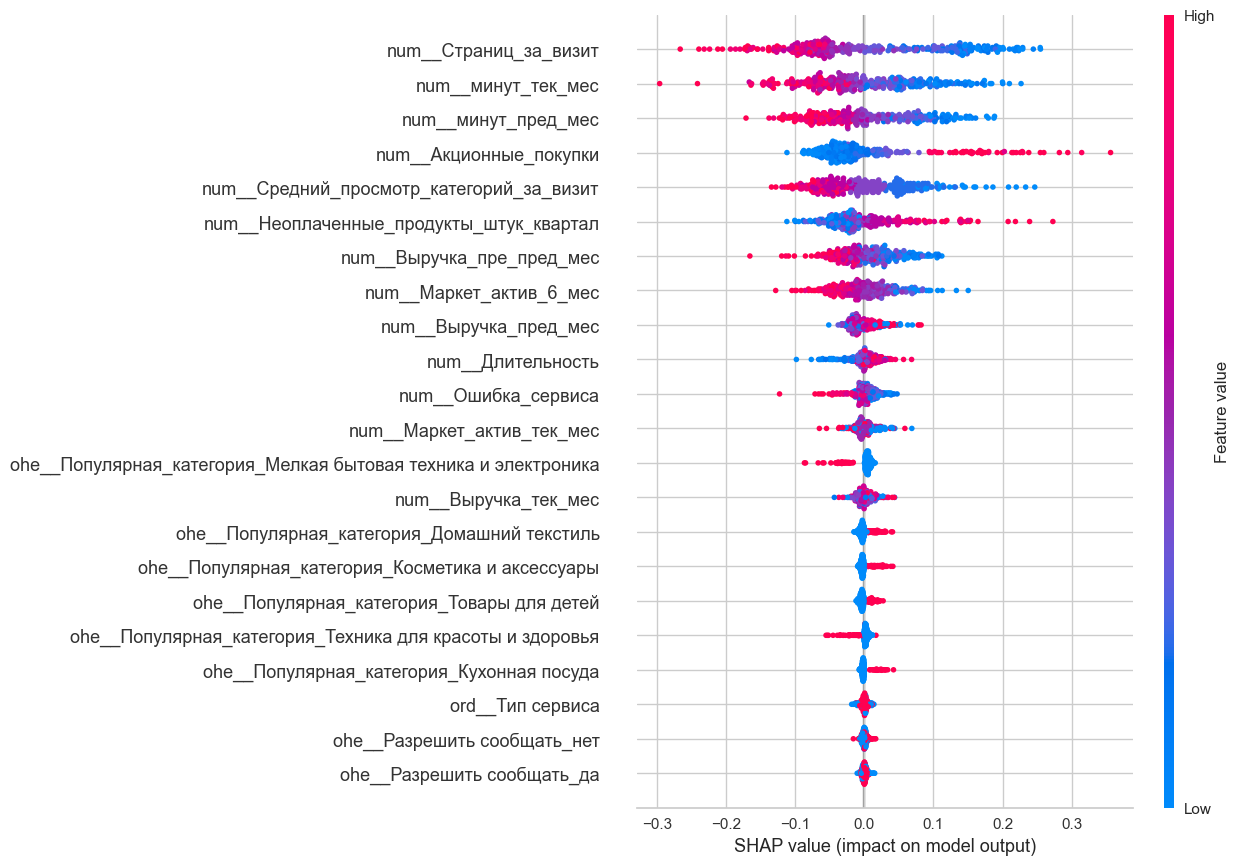

In [81]:
shap.plots.beeswarm(shap_values, max_display=22)

Рассмотрим результаты анализа для каждого признака:
- *Страниц_за_визит*: чем больше значение признака, тем меньше SHAP-значения объектов. Если у объекта высокое значение данного признака, то модель с большой вероятность присвоит ему класс 0 (в нашем случае - "прежний уровень")


- *минут_пред_месяц*: чем больше значение признака, тем меньше SHAP-значения объектов. Если у объекта высокое значение данного признака, то модель с большой вероятность присвоит ему класс 0 (в нашем случае - "прежний уровень")


- *Акционные_покупки*: SHAP-значения наблюдений по большей части группируются около значения -0.05. Чем меньше значение данного признака 


- *Средний_просмотр_категорий_за_визит*: чем больше значение признака, тем меньше SHAP-значения объектов. Если у объекта высокое значение данного признака, то модель с большой вероятность присвоит ему класс 0 (в нашем случае - "прежний уровень")


- *минут_тек_месяц*: чем больше значение признака, тем меньше SHAP-значения объектов. Если у объекта высокое значение данного признака, то модель с большой вероятность присвоит ему класс 0 (в нашем случае - "прежний уровень")


- *Неоплаченные_продукты_штук_квартал*: чем больше значение признака, тем больше SHAP-значения объектов. Если у объекта высокое значение данного признака, то модель с большей вероятностью присвоит ему класс 1 (то есть активнасть "снизилась").


- При высоких значениях признаков *Маркет_актив_тек_мес* и *выручка_пре_пред_мес* модель с большей вероятностью присвоит наблюдениям класс 0 ("прежний уровень").


- По признаку *Маркет_актив_6_мес* наблюдения и с высокими, и с низкими значениями имеют как положительные, так и отрицательные SHAP-значения. Признак оказывает несущественное влияние на определение класса объекта.


- Какая именно категория является популярной мало влияет на определение определение моделью типа активности покупателя.


- Неоднозначный результат получился по признаку "ошибка сервиса". Чем больше пользователи сталкиваются с ошибками сервиса, тем вероятнее их активность модель промаркирует как "прежний уровень". Такие результаты можно объяснить так: пользователи с низкой активностью редко заходят на сайт, а значит сталкиваются с меньшим числом ошибок.


- Признаки *длительность*, *тип сервиса* и *разрешить сообщать* мало влияют на определение типа активности покупателей.

Для того, чтобы понять влияние каждого признака на формирование прогнозных значений в целом построим столбчатую диаграмму по модулям средних shap-значений.

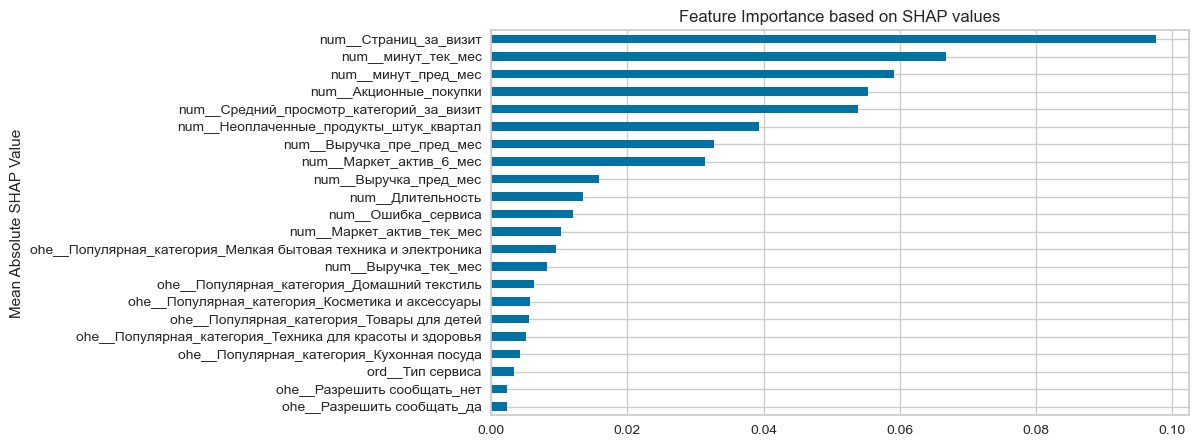

In [82]:
abs_mean = np.abs(shap_values.values).mean(axis=0)

# Создаем DataFrame или Series с именами признаков
feature_names = shap_values.feature_names
abs_mean_series = pd.Series(abs_mean, index=feature_names)

# Строим bar chart
plt.figure(figsize=(9,5))
abs_mean_series.sort_values(ascending=True).plot(kind='barh')
plt.ylabel('Mean Absolute SHAP Value')
plt.title('Feature Importance based on SHAP values')
plt.show()

Таким образом, на основе графиков выше можно выделить наиболее и наименее значимые признаки.

Наиболее важными признаками являются:
 - Страниц_за_визит (описывает поведение на сайте)
 - минут_пред_мес (описывает поведение на сайте)
 - минут_тек_мес (описывает поведение на сайте)
 - акционные_покупки (описывает финансовое поведение)
 - средний_просмотр_категорий_за_визит (описывает продуктовое поведение)
 - неоплаченные_продукты_штук_квартал (описывает продуктовое поведение)
 
Исходя из списка выше, можно сделать вывод о том, что на определение предполагаемого типа активности покупателя (снизится или останется на прежнем уровне) наибольшее влияние оказывают признаки, описывающие поведение покупателя на сайте и его продуктовое поведение.

Наименее значимыми признаками являются:
- выручка_пред_мес (описывает финансовое поведение)
- выручка_тек_мес (описывает финансовое поведение)
- популярная категория (описывает продуктовое поведение)
- тип сервиса (описывает коммуникацию с клиентом)
- разрешить сообщать (описывает коммуникацию с клиентом)

С учетом полученных результатов, можно сказать, что не все признаки являются необходимыми для построения прогноза покупательской активности в ближайшие три месяца. Это значит, что общее число входящих признаков можно сократить и посмотреть, как измениться метрика модели.



**Выводы:**
- Был проведен анализ признаков с помощью SHAP-значений.
- Выявлены наиболее и наименее важные признаки для модели. В число наиболее важных признаков вошли те, которые описывают поведение покупателя на сайте и продуктовое поведение, а именно: Страниц_за_визит, минут_пред_мес, популярная_категория, минут_тек_мес, средний_просмотр_категорий_за_визит, неоплаченные_продукты_штук_квартал.
- В число наименее важных признаков вошли: выручка_пред_мес, ошибка_сервиса, акционные_покупки, выручка_тек_мес, длительность, тип сервиса, разрешить сообщать.
- Часть наименее важных признаков для модели были удалены. При этом качество модели не снизилось.
- Также стоит обратить внимание, что в число наиболее важных признаков не вошли признаки, описывающие финансовое поведение и коммуникацию с покупателем. Больше всего на клиентский опыт и их дальнейшую активность влияет пользовательский опыт использования сайта и продуктовый ассортимент (наиболее приоритетные области для развития с учетом задачи созранения активности клиентов).

## Сегментация покупателей
<a id="customers"></a>

На примере выделенной группы покупателей (сегменте) проанализируем результаты модели и выявим предаолагаемые способы увеличения активности.

В качестве сегмента отберем покупателей, с высокой вероятностью снижения активности, но при этом со значимой маркетинговой активностью в последние 6 месяцев. 

Для начала, подготовим необходимый пул данных для анализа. Определим, какой уровень маркетинговой активности можно считать "высоким".

In [83]:
median = np.median(market_file['Маркет_актив_6_мес'])
mode = market_file['Маркет_актив_6_мес'].mode()
mean = market_file['Маркет_актив_6_мес'].mean()
print(f'Медианное значение маркетинговой активности: {median}')
print(f'Среднее значение маркетинговой активности: {round(mean,1)}')
print(f'Мода значений маркетинговой активности: {mode[0]}')

Медианное значение маркетинговой активности: 4.2
Среднее значение маркетинговой активности: 4.3
Мода значений маркетинговой активности: 4.1


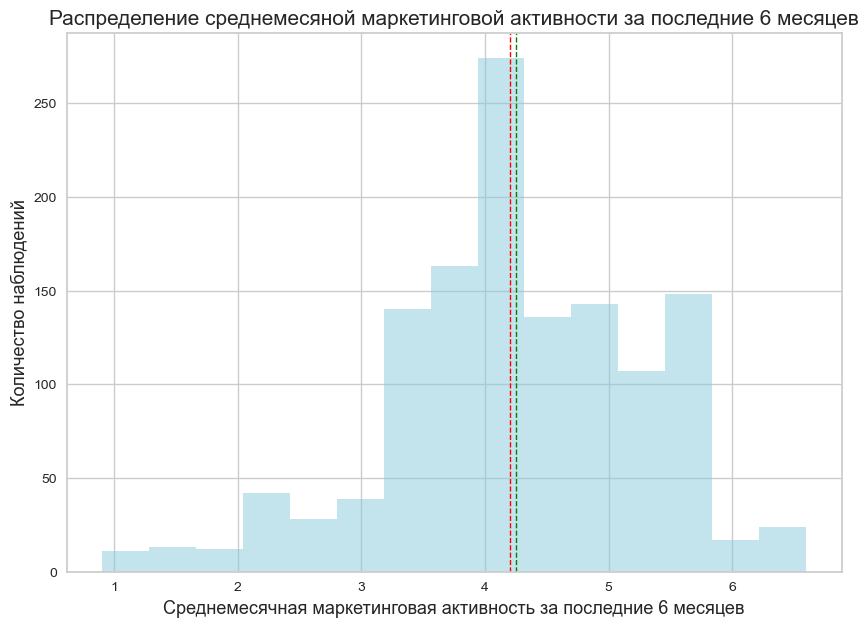

In [84]:
plt.figure(figsize=(10,7))
plt.hist(market_file['Маркет_актив_6_мес'], bins=15, color='c', alpha=0.5)
plt.axvline(median, color='red', linestyle='dashed', linewidth=1,label=f'Медиана: {median:.2f}')
plt.axvline(mean, color='green', linestyle='dashed', linewidth=1,label=f'Среднее: {mean:.2f}')
plt.xlabel('Среднемесячная маркетинговая активность за последние 6 месяцев', size=13)
plt.ylabel('Количество наблюдений', size=13)
plt.title('Распределение среднемесяной маркетинговой активности за последние 6 месяцев', size=15)
plt.show()

Исходя из полученного графика, а также медианного и среднего значений, примем, что высокой маркетинговой активностью считается значение выше среднего, то есть больше 4.3 по признаку Маркет_актив_6 _мес. Отберем соответствующие данные.

In [85]:
y_pred_f = pd.DataFrame(y_pred, columns=['Покупательская активность'], index=X_test.index)

In [86]:
customer_pool = pd.concat([X_test, y_pred_f], axis=1)
customer_pool.shape

(325, 17)

In [87]:
customer_pool.head()

,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит,Выручка_тек_мес,Выручка_пред_мес,Выручка_пре_пред_мес,минут_тек_мес,минут_пред_мес,Покупательская активность
id,,,,,,,,,,,,,,,,,
216446,стандарт,да,5.3,5,433,0.91,Техника для красоты и здоровья,1,1,0,7,5230.7,4712.0,5160.0,20,15,0
215469,премиум,да,4.1,3,813,0.22,Домашний текстиль,3,3,4,5,5228.0,5403.5,4889.0,8,12,1
216301,премиум,да,3.9,5,410,0.20,Косметика и аксесcуары,3,1,5,14,4926.4,5052.5,5348.0,13,17,0
215713,стандарт,да,4.6,5,293,0.24,Товары для детей,1,3,3,3,5221.4,4821.0,4872.0,14,12,1
215500,стандарт,да,3.5,4,573,0.40,Косметика и аксесcуары,2,4,1,4,3808.1,4137.0,4278.0,12,11,1


Из таблицы customer_pool отберем только наблюдения, у которых значение признака маркетинговая активность в послдение 6 месяцев выше 4.3.

In [88]:
customer_pool_f = customer_pool[customer_pool['Маркет_актив_6_мес']>4.3].reset_index(drop=False)
print(customer_pool_f.shape)
customer_pool_f.head()

(131, 18)


,id,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит,Выручка_тек_мес,Выручка_пред_мес,Выручка_пре_пред_мес,минут_тек_мес,минут_пред_мес,Покупательская активность
0,216446,стандарт,да,5.3,5,433,0.91,Техника для красоты и здоровья,1,1,0,7,5230.7,4712.0,5160.0,20,15,0
1,215713,стандарт,да,4.6,5,293,0.24,Товары для детей,1,3,3,3,5221.4,4821.0,4872.0,14,12,1
2,216575,премиум,да,4.5,4,482,0.25,Косметика и аксесcуары,3,2,2,9,5769.8,5567.0,5483.0,22,8,0
3,216533,стандарт,нет,5.7,5,769,0.14,Техника для красоты и здоровья,4,1,8,10,5180.3,5868.0,4925.0,20,15,0
4,216356,стандарт,да,5.5,4,1022,0.91,Мелкая бытовая техника и электроника,3,0,3,11,6071.6,5542.5,5082.0,6,13,1


В выбранном сегменте оказалось 131 наблюдение. Для формирования предложения по поддержанию активности таких покупателей, проанализируем признаки. Сосредоточимся на признаках, описывающих поведение на сайте и продуктовое поведение.

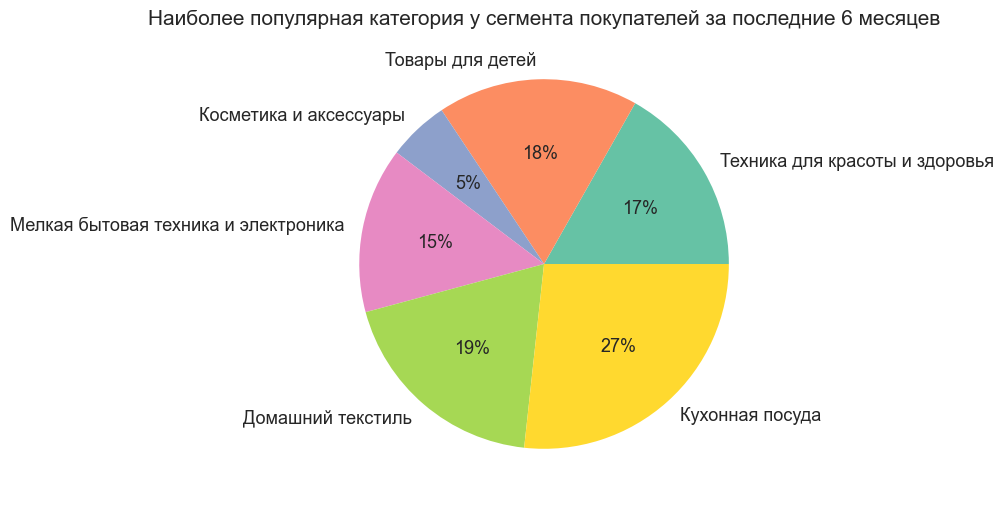

In [89]:
(customer_pool_f
 .pivot_table(index='Популярная_категория', values='id', aggfunc='count')
 .reset_index()
 .plot(kind='pie', x='Популярная_категория', y='id', figsize=(10,6), labels=customer_pool_f['Популярная_категория'].unique(),\
       autopct = "%.0f%%", ylabel='', textprops={'fontsize':13}, colors=sns.color_palette('Set2'), legend=None)
)
plt.title('Наиболее популярная категория у сегмента покупателей за последние 6 месяцев', size=15)
plt.show()

У выбранного сегмента покупателей можно выделить следкющую особенность: наиболее популярными категориями являются товары не повседнего спроса (техника, косметика и аксесуары, кухонная посуда). С учетом популярности категории *Косметика и аксесуары* и *мелкая бытовая техника*, есть потенциал для роста категории *техника для красоты и здоровья*.

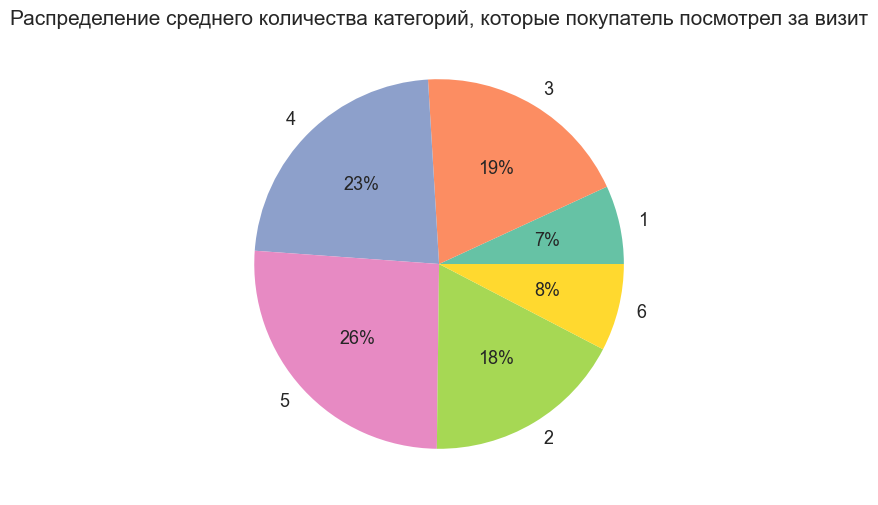

In [90]:
(customer_pool_f
 .pivot_table(index='Средний_просмотр_категорий_за_визит', values='id', aggfunc='count')
 .reset_index()
 .plot(kind='pie', x='Средний_просмотр_категорий_за_визит', y='id', figsize=(10,6), \
       labels=customer_pool_f['Средний_просмотр_категорий_за_визит'].unique(),\
       autopct = "%.0f%%", ylabel='', textprops={'fontsize':13}, colors=sns.color_palette('Set2'), legend=None)
)

plt.title('Распределение среднего количества категорий, которые покупатель посмотрел за визит', size=15)
plt.show()

Примерно треть покупателей сегмента в среднем просматривают менее 4 категорий. Необходимо привлечь их внимание и к другим категориям, что позволит увеличить покупки товаров из других категорий и повысит активность пользователей на сайте.

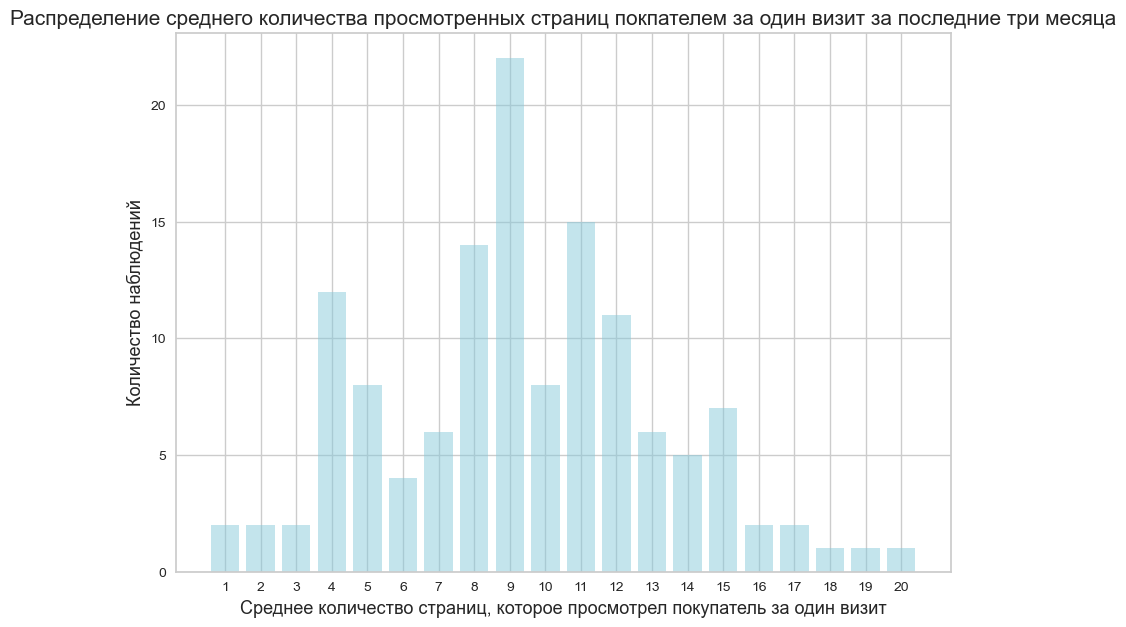

In [91]:
plt.figure(figsize=(10,7))
list_x = customer_pool_f['Страниц_за_визит'].value_counts().sort_values(ascending=False).index
plt.bar(x=list_x, \
        height=customer_pool_f['Страниц_за_визит'].value_counts(),\
        color='c', alpha=0.5)
plt.xlabel('Среднее количество страниц, которое просмотрел покупатель за один визит', size=13)
plt.ylabel('Количество наблюдений', size=13)
plt.xticks(list_x)
plt.title('Распределение среднего количества просмотренных страниц покпателем за один визит за последние три месяца', size=15)
plt.show()

Не смотря на то, что с данным сегментом проводится активная маркетинговая коммуникация, больше половины покупателей в пуле в среднем проссматривают меньше 10 страниц.

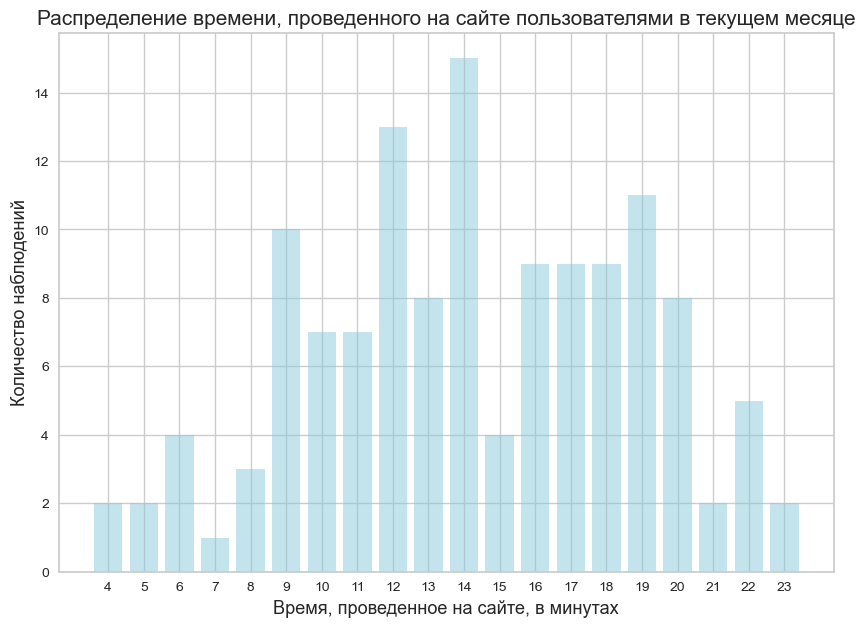

In [92]:
plt.figure(figsize=(10,7))
list_x = customer_pool_f['минут_тек_мес'].value_counts().sort_values(ascending=False).index
plt.bar(x=list_x, \
        height=customer_pool_f['минут_тек_мес'].value_counts(),\
        color='c', alpha=0.5)
plt.xlabel('Время, проведенное на сайте, в минутах', size=13)
plt.ylabel('Количество наблюдений', size=13)
plt.xticks(list_x)
plt.title('Распределение времени, проведенного на сайте пользователями в текущем месяце', size=15)
plt.show()

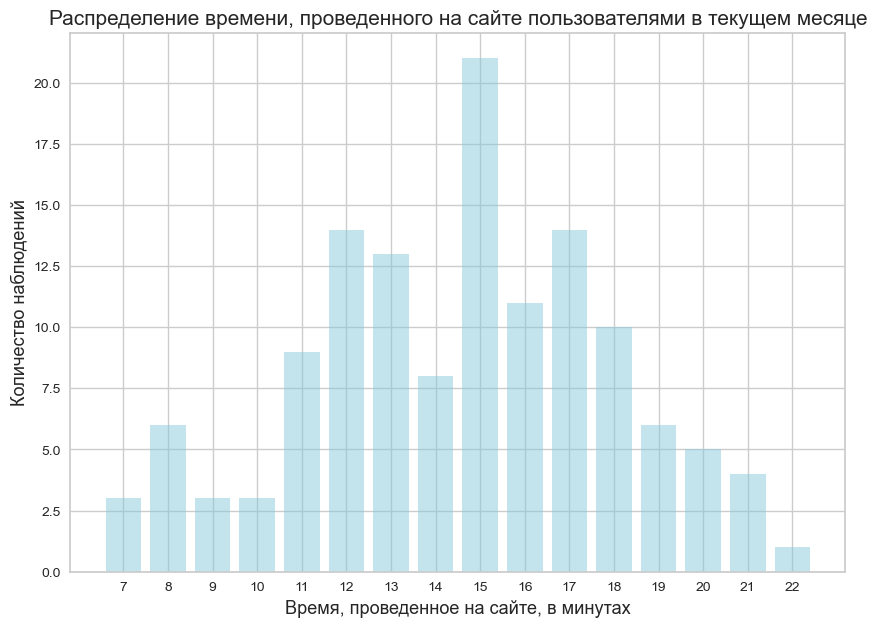

In [93]:
plt.figure(figsize=(10,7))
list_x = customer_pool_f['минут_пред_мес'].value_counts().sort_values(ascending=False).index
plt.bar(x=list_x, \
        height=customer_pool_f['минут_пред_мес'].value_counts(),\
        color='c', alpha=0.5)
plt.xlabel('Время, проведенное на сайте, в минутах', size=13)
plt.ylabel('Количество наблюдений', size=13)
plt.xticks(list_x)
plt.title('Распределение времени, проведенного на сайте пользователями в текущем месяце', size=15)
plt.show()

Если посмотреть на два графика выше, то можно заметить, что распределение проведенного пользователями времени на сайте от месяуа к месяцу уменьшилось. Необходимо поддержить время проведенное на сайте, так как это является важным фактором в определении активности покупателя. Как рекоммендацию (с учетом того, что маркет активность в последнии 6 месяцев у данных пользователей высокая) можно предложить расширение ассортимента товара/ добавление новых категорий товаров.

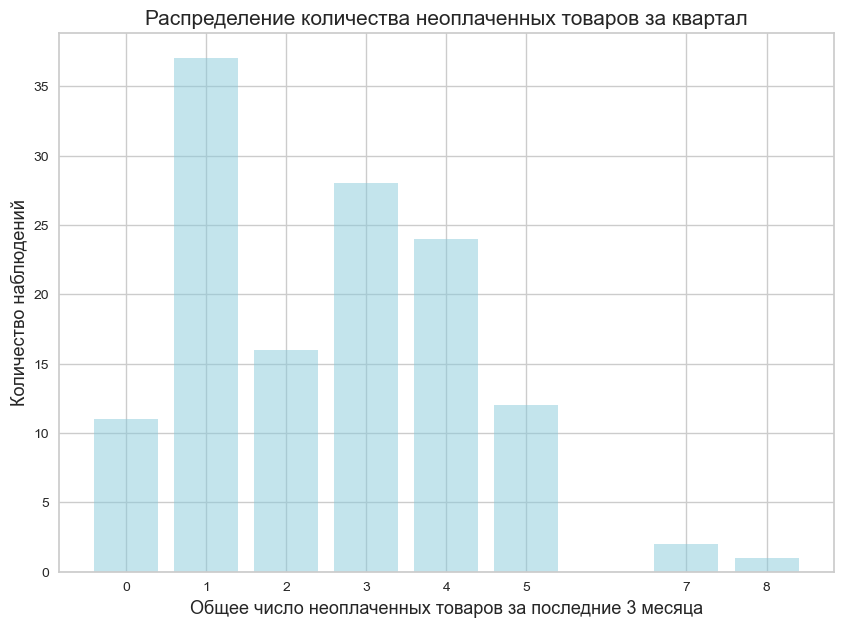

In [94]:
plt.figure(figsize=(10,7))
list_x = customer_pool_f['Неоплаченные_продукты_штук_квартал'].value_counts().sort_values(ascending=False).index
plt.bar(x=list_x, \
        height=customer_pool_f['Неоплаченные_продукты_штук_квартал'].value_counts(),\
        color='c', alpha=0.5)
plt.xlabel('Общее число неоплаченных товаров за последние 3 месяца', size=13)
plt.ylabel('Количество наблюдений', size=13)
plt.xticks(list_x)
plt.title('Распределение количества неоплаченных товаров за квартал', size=15)
plt.show()

При исследовании исходного датасета в основном у покупателей количество неоплаченных товаров в корзине составляло от 0 до 5, у меньшинства - от 7 до 8. В целом, данные по сегменту не выбиваются из общих значений.

**Вывод:**
- Пользователи из выбранного сегмента в ппоследние месяцы стали меньше времени тратить на визит на сайт.
- Треть покупателей, не смотря на активное маркетинговое взаимодействие, в среднем проссматривает менее трех категорий.
- Наиболее популярными категориями товаров для данного сегмента покупателей является куханные принадлежности, мелкая бытовая техника и косметика и аксессуары.

**Рекомендации по удержанию активности покупателей выбранного сегмента:**
- расширить асортимент товаров, особенно в потенциально популярных категориях;
- добавить новые категории товаров на сайт;
- пересмотреть маркетинговую стратегию, так как она является немаловажным компонетом удержания внимания и заинтересованности покупателя.

В целом у данного сегмента покупателей просматриваются аналогичные закономерности в признаках, как и в общем объеме данных. Что может означать, что маркетинговые коммуникации могут быть более эффективны. Также часть предложенных рекомендаций направлена на поддержание интереса клиентов без использования маркетинговых инструментов.

## Общие выводы
<a id="conclusion"></a>

В рамках проекта необходимо было проработать модель для интернет магазина. Целью построения модели было выявление покупателей, активность которых вероятно снизиться в ближайшее время. В случае маркировки покупателя "со сниженной активностью" магазин мог бы оперативно применить различные подходы по удержанию внимания и интереса клиентов, что позволило бы избежать потери выручки и способствовать ее росту.

**Предобработка данных:**


- во всех датасетах была проведена проверка наличия неявных и явных дубликатов. В датасетах `market_file` и `market_time` значения были обработаны в соответствие с выявленными факторами.


- данные были проверены на наличие аномалий. В датасете `market_money` было выявлено аномально высокое значение выручки в месяц по одному из клиентов. Данное значение было обработано.

**Исследовательский анализ данных:**


- По распределению покупательской активности видно, что у 62% покупателей снизилась покупательская активность. Необходимо проанализировать другие признаки, чтобы понять, с чем может быть связан такой результат.


- Большинство покупателей пользуются уровнем сервиса "стандарт" - 71% от общего числа покупателей.


- Большинство покупателей (74%) дало свое согласие, на получение дополнительной информации о товаре.


- За последние шесть месяцев значение среднемесячной маркетинговой активности в большинстве случаев составляло от 3 до 6. Также виден пик в районе значения 4.


- В текущем месяце количество маркетинговых коммуникаций с клиентами принимало значения 3, 4 и 5. Чуть больше половины клиентов в текущем месяце получили маркетинговые рассылки/ звонки/ показ рекламы 4 раза. Четверть клиентов 5 раз была задействована в маркетинговых коммуникациях и оставшаяся четверть - 3 раза.


- Пользователи в выборке зарегистрированы на сайте примерно от 100 до 1100 дней. При этом стоит отметить, что на гистрограмме нет сильно выдающихся пиков (вероятно не было периодов, когда резко увеличивалось количество регистраций на сайте). Минимальное значение длительности регистрации на сайте составляет около 100 дней, то есть последний зарегистрированный пользователь пришел около ста дней назад.


- чаще всего средняя доля акционных покупок пользователей составляла от 10% до 40%. Также видена небольшая группа пользователей, среднемесячная доля покупок которых составляет около 90% - они покупают в основном только акционные продукты.


- Всего на сайте представлено 6 категорий товаров. Наиболее популярной категорией является мелкая бытовая техника и электроника (25%). Далее по популярности идут категории Товары для детей (19%) и Домашний текстиль (17%). 


- Чаще всего за один визит покупатели просматривают от 3 до 5 категорий. Горахдо  еньший процент позьзователей за визит просматривает 2, 1 или 6 категорий товаров.


- У большинства клиентов за послений квартал было от 1 до 5 неоплаченных товаров. Гораздо меньшее количество клиентов в последнем квартале имело от 6 до 10 неоплаченных товаров в корзине.


- В целом пользователи сталкивались максимум с 9 сбоями при визите сайта. В основном, количество сбоев, коснувшихся покупателей, составляет 4. Стоит обратить внимание на стабильность работы сайта.

- Покупатели с нулевой выручкой практически отсутствуют. В текщем месяце таких покупателей не было совсем, в два предыдущих периода - по 3 покупателя.


- В среднем в месяц один покупатель совершает покупки на сумму около 5 тысяч. В текущем месяца самое высокое значение среднемесячного чека - чуть больше 5 тысяч рублей.

**Проработка модели:**



**Рекомендации по удержанию активности покупателей выбранного сегмента:**
- расширить асортимент товаров, особенно в потенциально популярных категориях;
- добавить новые категории товаров на сайт;
- пересмотреть маркетинговую стратегию, так как она является немаловажным компонетом удержания внимания и заинтересованности покупателя.

В целом у данного сегмента покупателей просматриваются аналогичные закономерности в признаках, как и в общем объеме данных. Что может означать, что маркетинговые коммуникации могут быть более эффективны. Также часть предложенных рекомендаций направлена на поддержание интереса клиентов без использования маркетинговых инструментов.